# **Subjektivní analýza novinových článků**

Tématem projektu jsme si zvolili **Subjektivní analýzu novinových článků** — zajímalo nás, jestli se dá z textu vyčíst, jak moc je autor zaujatý, aniž bychom museli článek číst celý.

Původní nápad byl jednoduchý: novináři píšou různě — někteří věcně, jiní s jasným názorovým zabarvením. Chtěli jsme zjistit, zda to dokáže poznat i počítač. Rozhodli jsme se tedy ukázat víc přístupů jak toho dosáhnnout najednou a to jak jednoduchým vlastním index, tak sofistikovaným BERT modem. Nakonec vše porovnat a zjistit jak moc se jejich výsledky liší.

### Stažení potřebných knihoven

Knihovny jsme vybírali postupně podle toho, co jsme potřebovali. Část jsme znali z cvičení (Hugging Face / transformers), část nám doporučil chatbot nebo jsme na ně narazili při hledání jak scrapovat české weby.

- **newspaper3k**: První věc, na kterou jsme narazili při hledání jak stáhnout novinové články — umí automaticky vytáhnout text, autora i datum. Pro české weby ale potřebuje trochu pomoct, takže jsme přidali vlastní logiku přes BeautifulSoup.
- **lxml_html_clean**: Nutný pomocník pro newspaper3k, čistí HTML před parsováním.
- **transformers** + **torch**: Hugging Face ekosystém — používáme ho na dva účely: vícejazyčný BERT model pro analýzu sentimentu a český NER model `richielo/small-e-czech-finetuned-ner-wikiann` pro rozpoznávání pojmenovaných entit.
- **stanza**: Stanford NLP knihovna s podporou češtiny — potřebovali jsme spolehlivý POS tagger a lemmatizér pro český text, a tohle bylo nejlepší co jsme našli.
- **gensim**: Použili jsme ji pro Word2Vec a LDA. Líbilo se nám, že je rychlá a dobře zdokumentovaná.
- **wordcloud**: Čistě pro vizualizaci — wordcloudy jsou jednoduché na pochopení a při prezentaci dobře vypadají.
- **scikit-learn**: Klasika pro TF-IDF vektorizaci — spolehlivá, rychlá, dobře dokumentovaná.
- **requests**: Základní HTTP knihovna, potřebná pro stahování stránek.

In [ ]:
!pip install newspaper3k lxml_html_clean transformers torch requests stanza gensim spacy wordcloud scikit-learn

  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.4/6.4 MB 6.0 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 658.0/658.0 kB 2.2 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 815.4/815.4 kB 9.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 9.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 7.2 MB/s  0:00:01 eta 0:00:01
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17/17 [spacy]m16/17 [spacy]-learn]

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


### 1. & 2. Sběr a extrakce textu z článků

Jako zdroj dat jsme vybrali **SeznamZprávy** — jsou to české zprávy, mají přehlednou strukturu a článků je tam dost. Původně jsme zkusili jen `newspaper3k` a doufali, že si poradí sama, ale u českých stránek to nefunguje spolehlivě — nadpisy a autory občas nezachytí vůbec.

Nakonec jsme ji zkombinovali s **BeautifulSoup** a přidali vlastní fallbacky přes JSON-LD meta tagy, které moderní zpravodajské weby standartně používají. Tahle vrstvená logika (JSON-LD → meta tagy → newspaper3k záloha) nám dala nejspolehlivější výsledky ze všeho co jsme zkoušeli.

**Definice scrapovací funkce:**

In [ ]:
from newspaper import Article, build, Config
import requests
from bs4 import BeautifulSoup
import json

def get_articles_from_url(base_url, num_articles=None):
    config = Config()
    config.browser_user_agent = 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/119.0.0.0 Safari/537.36'
    config.request_timeout = 70

    print(f"Pokouším se stáhnout články z: {base_url}")
    try:
        paper = build(base_url, config=config, memoize_articles=False)
        print(f"Nalezeno {len(paper.articles)} potenciálních článků.")
    except Exception as e:
        print(f"Chyba při načítání stránek nebo budování zdroje: {e}")
        return []

    articles_data = []
    filtered_articles = [article_obj for article_obj in paper.articles if '/clanek/' in article_obj.url]
    print(f"Po filtrování podle '/clanek/' zbývá {len(filtered_articles)} potenciálních článků.")

    for i, article_obj in enumerate(filtered_articles):
        if num_articles is not None and i >= num_articles:
            break
        try:
            article = Article(article_obj.url, config=config)
            article.download()
            article.parse()

            soup = None
            if article.html:
                soup = BeautifulSoup(article.html, 'lxml')

            # --- EXTRAKCE TITULKU ---
            if not article.title and soup:
                og_title = soup.find('meta', property='og:title')
                if og_title and og_title.get('content'):
                    article.title = og_title['content'].strip()
                elif soup.title:
                    article.title = soup.title.get_text(strip=True).replace(' - Seznam Zprávy', '')
                else:
                    h1_tag = soup.find('h1')
                    if h1_tag:
                        article.title = h1_tag.get_text(strip=True)

            # --- EXTRAKCE AUTORA A DATA PUBLIKACE (PŘES JSON-LD) ---
            authors_list = article.authors
            publish_date = None # Začínáme s None, chceme ideálně přesný ISO string z HTML

            if soup:
                for script in soup.find_all('script', type='application/ld+json'):
                    try:
                        data = json.loads(script.string)
                        if isinstance(data, list):
                            data = data[0] # Vezmeme první prvek, pokud jde o seznam

                        # Hledáme schema.org typy pro články
                        if isinstance(data, dict) and data.get('@type') in ['NewsArticle', 'Article', 'ReportageNewsArticle']:

                            # Vytáhneme datum
                            if not publish_date and data.get('datePublished'):
                                publish_date = data.get('datePublished')

                            # Vytáhneme autory
                            if not authors_list:
                                author_data = data.get('author')
                                if isinstance(author_data, list):
                                    authors_list = [a.get('name') for a in author_data if isinstance(a, dict) and a.get('name')]
                                elif isinstance(author_data, dict) and author_data.get('name'):
                                    authors_list = [author_data.get('name')]
                    except (json.JSONDecodeError, TypeError, AttributeError):
                        continue

            # --- ZÁLOŽNÍ EXTRAKCE DATA PUBLIKACE (Meta tagy) ---
            if not publish_date and soup:
                # Nejspolehlivější meta tag pro zpravodajské weby
                meta_time = soup.find('meta', property='article:published_time')
                if meta_time and meta_time.get('content'):
                    publish_date = meta_time['content'].strip()
                else:
                    # Klasický schema.org meta tag
                    meta_date = soup.find('meta', attrs={'itemprop': 'datePublished'})
                    if meta_date and meta_date.get('content'):
                        publish_date = meta_date['content'].strip()

            # Fallback na původní knihovnu newspaper3k (kdyby všechno ostatní selhalo)
            if not publish_date and article.publish_date:
                # Newspaper3k často vrací 'datetime' objekt. Převedeme ho na text, ať je to konzistentní
                publish_date = article.publish_date.strftime('%Y-%m-%dT%H:%M:%S')

            # --- ZÁLOŽNÍ EXTRAKCE AUTORA (Meta tag) ---
            if not authors_list and soup:
                meta_author = soup.find('meta', attrs={'name': 'author'})
                if meta_author and meta_author.get('content'):
                    authors_list = [meta_author['content'].strip()]


            # --- UKLÁDÁNÍ VÝSLEDKŮ ---
            if article.text and article.title:
                articles_data.append({
                    'url': article.url,
                    'title': article.title,
                    'authors': authors_list,
                    'publish_date': publish_date, # Nyní spolehlivě v ISO 8601 formátu
                    'text': article.text
                })
                print(f"Stažen článek {i+1}: {article.title} | Datum: {publish_date} | Autoři: {', '.join(authors_list) if authors_list else 'Neznámý'}")
            else:
                print(f"Článek {i+1} z {article_obj.url} neobsahuje text nebo titulek, přeskočen.")

        except Exception as e:
            print(f"Chyba při stahování nebo parsování článku z {article_obj.url}: {e}")
            continue

    return articles_data

**Spuštění scrapování** z www.seznamzpravy.cz/

Pár věcí, které jsme při testování zjistili:
- Spousta článků se přeskočí kvůli chybějícímu nadpisu — to nám ale nevadí, raději méně dat než špatná data.
- Přidali jsme **caching do souboru** (`articles_cache.json`) — při vývoji jsme nechtěli při každém restartu čekat minuty na stahování a zároveň riskovat dočasné zablokování ze strany serveru.

In [ ]:
import pandas as pd
import os, json as _json

CACHE_FILE = "articles_cache.json"

# Počet článků ke stažení (zvyšte pro přesnější analýzu, ideálně 50+)
num_articles_to_download = 120

if os.path.exists(CACHE_FILE):
    print(f"📂 Načítám data z cache: {CACHE_FILE}")
    articles_df = pd.read_json(CACHE_FILE, orient="records")
    print(f"   Načteno {len(articles_df)} článků.")
    display(articles_df[["url", "title", "authors", "publish_date"]].head())
else:
    print("🌐 Cache neexistuje — stahuji z webu...")
    seznam_zpravy_articles = get_articles_from_url(
        "https://www.seznamzpravy.cz/", num_articles=num_articles_to_download
    )

    if seznam_zpravy_articles:
        articles_df = pd.DataFrame(seznam_zpravy_articles)
        articles_df.to_json(CACHE_FILE, orient="records", force_ascii=False, indent=2)
        print(f"💾 Uloženo do cache: {CACHE_FILE}")
        display(articles_df[["url", "title", "authors", "publish_date"]].head(num_articles_to_download))
    else:
        print("Nebyly staženy žádné články nebo došlo k chybě.")

🌐 Cache neexistuje — stahuji z webu...
Pokouším se stáhnout články z: https://www.seznamzpravy.cz/
Nalezeno 110 potenciálních článků.
Po filtrování podle '/clanek/' zbývá 101 potenciálních článků.
Článek 1 z https://www.seznamzpravy.cz/clanek/zdravi-plus-mapa-ortopedu-ordinace-praha-vsechny-kraje-301728 neobsahuje text nebo titulek, přeskočen.
Článek 2 z https://www.seznamzpravy.cz/clanek/domaci-kauzy-policejni-navsteva-ustecke-kliniky-detektivove-opet-cili-na-podezrele-operace-306097 neobsahuje text nebo titulek, přeskočen.
Stažen článek 3: Berou sto tisíc, je jim přes 30 a žijí ve spolubydlení. Bude jich víc | Datum: 2026-05-14T05:00:00.000Z | Autoři: Markéta Bidrmanová
Stažen článek 4: Kdy jsou opravdu potřeba antibiotika a jak přesně působí | Datum: 2026-05-14T06:00:00.000Z | Autoři: Lucie Frydecká
Stažen článek 5: Schillerové protiinflační dluhopisy se vrací | Datum: 2026-05-14T11:22:53.000Z | Autoři: Markéta Bidrmanová
Stažen článek 6: V Havaně lidé protestovali kvůli nedostatku 

,url,title,authors,publish_date
0,https://www.seznamzpravy.cz/clanek/audio-podca...,"Berou sto tisíc, je jim přes 30 a žijí ve spol...",[Markéta Bidrmanová],2026-05-14T05:00:00.000Z
1,https://www.seznamzpravy.cz/clanek/audio-podca...,Kdy jsou opravdu potřeba antibiotika a jak pře...,[Lucie Frydecká],2026-05-14T06:00:00.000Z
2,https://www.seznamzpravy.cz/clanek/ekonomika-f...,Schillerové protiinflační dluhopisy se vrací,[Markéta Bidrmanová],2026-05-14T11:22:53.000Z
3,https://www.seznamzpravy.cz/clanek/zahranicni-...,V Havaně lidé protestovali kvůli nedostatku el...,[ČTK],2026-05-14T11:46:59.000Z
4,https://www.seznamzpravy.cz/clanek/sport-fotba...,Trenér Koubek nesouhlasí s vyřazením Chorého a...,[ČTK],2026-05-14T11:44:34.000Z
5,https://www.seznamzpravy.cz/clanek/ekonomika-f...,První malý modulární reaktor v Česku může být ...,[ČTK],2026-05-14T11:36:24.000Z
6,https://www.seznamzpravy.cz/clanek/domaci-cest...,"Češtinu kazí především politici a média, kriti...",[Fórum čtenářů],2026-05-14T09:30:00.000Z
7,https://www.seznamzpravy.cz/clanek/domaci-jede...,"Jeden z Babišovy party padl, druhý přichází. Č...",[David Klimeš],2026-05-14T05:30:00.000Z
8,https://www.seznamzpravy.cz/clanek/domaci-zivo...,Proočkovanost proti covidu se dramaticky propa...,[Josef Mačí],2026-05-14T04:20:00.000Z
9,https://www.seznamzpravy.cz/clanek/ekonomika-b...,Železniční megatendr vrcholí. Vyhrát může jedi...,[Jan Richter],2026-05-14T07:45:00.000Z


### 3. Předzpracování textu

Než jsme mohli s textem cokoliv dělat analyticky, bylo potřeba ho vyčistit. Vybrali jsme standardní sadu kroků, kterou jsme znali z přednášek, ale u každého kroku jsme se zamýšleli, jestli dává pro naši úlohu smysl.

1. **Převod na malá písmena** — jednoznačné, „Vláda" a „vláda" jsou pro nás totéž.
2. **Odstranění interpunkce** — čárky a tečky nám nic neříkají o zaujatosti, jen komplikují porovnávání slov.
3. **Odstranění číslic** — kontroverzní krok, uznáváme. Data a čísla mohou být důležitá, ale pro analýzu subjektivity jsme usoudili, že jsou spíš šum než signál.
4. **Odstranění stop slov** — sestavili jsme vlastní seznam českých stop slov, protože existující knihovny ho mají nedostatečný. Bez toho by „a", „je", „na" dominovaly ve všech výsledcích.
5. **Sjednocení mezer** — technická nutnost po předchozích krocích.

**Definice funkcí:**

In [ ]:
import re
import string

# Česká stop slova — rozšířený seznam
czech_stop_words = set([
    # ── základní sloveso být ──
    "být", "býti", "byt", "byv", "byvše", "byvši",
    "je", "jsem", "jsi", "jsme", "jsou", "jste",
    "jsem-li", "jsi-li", "jsme-li", "jsou-li", "jste-li",
    "jsa", "jsouc", "jsouce",
    "byl", "byla", "byli", "bylo", "byly",
    "byl-li", "byla-li", "byli-li", "bylo-li", "byly-li",
    "bylas", "bylos", "byls",
    "bude", "budeš", "budeme", "budete", "budou", "budu",
    "bude-li", "budeme-li", "budete-li", "budeš-li", "budou-li", "budu-li",
    "buď", "buďme", "buďte",
    "by",
    # ── osobní a přivlastňovací zájmena ──
    "já", "ty", "on", "ona", "ono", "oni", "ony",
    "my", "vy",
    "mě", "mně", "mi", "tě", "ti", "ho", "mu", "jej",
    "jeho", "její", "jejich", "jim", "jimi", "je", "ji", "jí",
    "nám", "nás", "vám", "vás",
    "náš", "naší", "naše", "naši",
    "váš", "vaše",
    "svůj", "svých", "svým", "svými", "své", "svou",
    "můj", "moje", "moji", "moja",
    # ── ukazovací a vztažná zájmena ──
    "ten", "ta", "to", "ti", "ty", "tato", "tento", "toto", "tyto",
    "tém", "tím", "tímto", "tohle", "toho", "tom", "tomto", "tomuto", "tuto", "teto",
    "který", "která", "které", "kteří", "kterou",
    "co", "což",
    "jenž", "jíž", "jehož",
    # ── neurčitá a záporná zájmena ──
    "nic", "nikdo", "něco", "někdo", "nějaký", "nijak",
    "žádný", "každý",
    # ── spojky ──
    "a", "ale", "ani", "anebo", "nebo", "i", "či",
    "aby", "protože", "proto", "takže", "tedy", "jenže",
    "ač", "ačkoli", "přestože", "dokud", "než", "nejen", "nýbrž",
    "když", "pokud", "jestli", "jestliže", "zda", "zdali",
    "jak", "jako", "také", "taky", "rovněž",
    # ── předložky ──
    "bez", "do", "k", "ke", "na", "nad", "o", "od", "po", "pod",
    "podle", "pro", "před", "přes", "při", "s", "se", "u", "v",
    "ve", "vedle", "vůči", "z", "za", "ze", "mezi", "mimo",
    "kromě", "díky", "kvůli", "během", "kolem",
    # ── příslovce a částice ──
    "ano", "ne", "asi", "ještě", "již", "jen", "jenom", "pouze",
    "pak", "tak", "taky", "také", "tedy", "právě", "vždy", "vůbec",
    "velmi", "dost", "hodně", "málo", "víc", "více", "méně",
    "spíše", "sice", "přece", "ovšem", "vlastně", "samozřejmě",
    "možná", "určitě", "opravdu", "docela", "celkem", "prostě",
    "tam", "zde", "kde", "kamkoli", "odkud", "potom", "zatím",
    "dnes", "teď", "pak", "tehdy", "stále", "furt",
    # ── tázací slova ──
    "kdo", "co", "kde", "kam", "kdy", "jak", "proč", "kolik", "který",
    # ── ostatní frekventovaná funkční slova ──
    "aj", "atd", "atp", "apod", "např", "tzn", "tzv",
    "si", "ho", "mi", "mu",
    "první", "jednou", "jeden",
    "další", "jiný", "celý", "různý",
    "dle", "pres", "vsak",
    # ── základní tvary frekventovaných sloves (lemmata po Stanza) ──
    "mít", "moci", "muset", "smět",
    "stát", "stávat",
    "jít", "přijít", "odejít",
    "dát", "dostat", "vzít",
    "říci", "říkat", "mluvit",
    "chtít", "vědět", "vidět",
    "dělat", "začít", "nechat", "zůstat",
    "platit", "řešit", "uvést", "najít", "dodat", "popisovat",
    # ── ohýbané tvary které projdou před lemmatizací ──
    "má", "mám", "mají", "měl", "měla", "měli", "mělo", "měly",
    "může", "mohu", "mohou", "mohl", "mohla", "mohli", "mohlo",
    "musí", "musel", "musela", "museli",
    "jde", "jdou", "šel", "šla", "šli",
    "stane", "stalo", "stal", "stala", "stali",
    "říká", "řekl", "řekla", "řekli", "řekne",
    "dal", "dala", "dali", "dá", "dají",
    "chce", "chtěl", "chtěla", "chtěli",
    "ví", "věděl", "věděla", "věděli",
    "vidí", "viděl", "viděla", "viděli",
    "dělá", "dělal", "dělala", "dělali",
    "není", "nejsou",
])

def to_lowercase(text):
    return text.lower()


def remove_punctuation(text):
    """Odstraní ASCII i Unicode interpunkci (české uvozovky, pomlčky, …)"""
    # ASCII interpunkce
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Unicode interpunkce: cokoliv co není písmeno, číslice ani mezera
    text = re.sub(r'[^\w\s]', ' ', text)
    return text


def remove_numbers(text):
    return re.sub(r'\d+', '', text)


def remove_stopwords(text, stop_words):
    words = text.split()
    return ' '.join(w for w in words if w not in stop_words)


def remove_short_words(text, min_len=3):
    """Odstraní slova kratší než min_len znaků (zbytky interpunkce, zkratky…)"""
    return ' '.join(w for w in text.split() if len(w) >= min_len)


def remove_extra_whitespace(text):
    return re.sub(r'\s+', ' ', text).strip()


def preprocess_text(text, stop_words):
    """Kompletní předzpracování textu pro NLP analýzu."""
    text = to_lowercase(text)
    text = remove_punctuation(text)
    text = remove_numbers(text)
    text = remove_stopwords(text, stop_words)
    text = remove_short_words(text)
    text = remove_extra_whitespace(text)
    return text

**Aplikace předzpracování na stažené články:**

In [ ]:
# Aplikujeme předzpracování na texty v DataFrame
if 'articles_df' in locals() and not articles_df.empty:
    articles_df['cleaned_text'] = articles_df['text'].apply(lambda x: preprocess_text(x, czech_stop_words))
    print("Předzpracování textu dokončeno. Zde je srovnání původního a vyčištěného textu pro první 3 články:")
    for i in range(min(3, len(articles_df))):
        print(f"\n--- Článek {i+1} ---")
        print(f"Původní: {articles_df.loc[i, 'text'][:300]}...") # Zobrazíme jen prvních 300 znaků
        print(f"Vyčištěný: {articles_df.loc[i, 'cleaned_text'][:300]}...")
else:
    print("DataFrame 'articles_df' neexistuje nebo je prázdný. Ujistěte se, že jste stáhli články dříve.")

Předzpracování textu dokončeno. Zde je srovnání původního a vyčištěného textu pro první 3 články:

--- Článek 1 ---
Původní: Spolubydlení už není výsadou studentů. Do sdílených bytů dnes míří i dobře vydělávající manažeři, kteří by si ještě nedávno koupili vlastní nemovitost. Investoři rozdělí byt klidně na čtyři jednotky, a tím zvýší výnosy.

Ještě před pár lety bylo spolubydlení určené hlavně pro studenty. Dneska ale v ...
Vyčištěný: spolubydlení výsadou studentů sdílených bytů míří dobře vydělávající manažeři nedávno koupili vlastní nemovitost investoři rozdělí klidně čtyři jednotky zvýší výnosy pár lety spolubydlení určené hlavně studenty dneska pokojích dvanáct patnáct osmnáct tisíc korun bydlí ajťáci manažeři konzultanti ban...

--- Článek 2 ---
Původní: Antibiotika často užíváme špatně. Není potřeba je brát vždy, když se objeví zelená rýma nebo výtok z oka. A vyhýbat bychom se měli hlavně těm, která máme nejraději – rychlým třídenním. Rozhodně nejsou šetrná.

Třídenní antibiotik

### 4. Part-of-Speech Tagging (POS Tagging) pomocí Stanza

Nápadem naší vlastní metody je, že **zaujatý autor používá víc přídavných jmen a příslovců** než objektivní zpravodaj. Aby to šlo měřit, potřebujeme ke každému slovu vědět, jakým slovním druhem je. K tomu slouží POS tagging.

Vybrali jsme **Stanza** od Stanford NLP, protože jako jediná z knihoven které jsme zkoušeli má solidní podporu pro češtinu a zvládá ji naučit bez ruční konfigurace. Bonus je, že dělá tokenizaci, lemmatizaci i POS tagging v jednom průchodu.

**Import a instalace:**

In [ ]:
!pip install stanza


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


**Stažení českého jazykového modelu** (jen při prvním spuštění, pak se načítá z cache):

In [ ]:
import stanza
import pandas as pd

# Stáhneme český model (pokud ještě není stažen)
stanza.download('cs')

# Inicializace pipeline pro češtinu
nlp = stanza.Pipeline('cs', processors='tokenize,lemma,pos')

def stanza_process_text(text):
    """Provede analýzu textu pomocí Stanza a vrátí POS tagy, lemmata a přídavná jména."""
    if not text or pd.isna(text):
        return [], "", []

    doc = nlp(text)
    pos_tags = []
    lemmas = []
    adjectives = []

    for sentence in doc.sentences:
        for word in sentence.words:
            pos_tags.append((word.text, word.upos))
            lemmas.append(word.lemma)
            if word.upos == 'ADJ':
                adjectives.append(word.lemma)

    return pos_tags, " ".join(lemmas), adjectives

if 'articles_df' in locals() and not articles_df.empty:
    print("Provádím analýzu textu pomocí Stanza (to může trvat déle)... ")

    # Aplikujeme Stanza na vyčištěný text
    results = articles_df['cleaned_text'].apply(stanza_process_text)

    # Uložení výsledků do DataFrame
    articles_df['pos_tags'] = [res[0] for res in results]
    articles_df['lemmatized_text'] = [res[1] for res in results]
    articles_df['adjectives_only'] = [res[2] for res in results]

    print("Analýza dokončena.")
    display(articles_df[['title', 'pos_tags', 'lemmatized_text']].head(5))
else:
    print("DataFrame 'articles_df' neexistuje nebo je prázdný.")

/opt/homebrew/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-05-14 13:56:27 INFO: Downloaded file to /Users/student/Library/Caches/stanza/1.11.0/resources/resources.json
2026-05-14 13:56:27 INFO: Downloading default packages for language: cs (Czech) ...
2026-05-14 13:56:28 INFO: File exists: /Users/student/Library/Caches/stanza/1.11.0/resources/cs/default.zip
2026-05-14 13:56:28 INFO: Finished downloading models and saved to /Users/student/Library/Caches/stanza/1.11.0/resources
2026-05-14 13:56:28 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES
2026-05-14 13:56:28 INFO: Downloaded file to /Users/student/Library/Caches/stanza/1.11.0/resources/resources.js

Provádím analýzu textu pomocí Stanza (to může trvat déle)... 
Analýza dokončena.


,title,pos_tags,lemmatized_text
0,"Berou sto tisíc, je jim přes 30 a žijí ve spol...","[(spolubydlení, NOUN), (výsadou, NOUN), (stude...",spolubydlení výsada student sdílený byt mířit ...
1,Kdy jsou opravdu potřeba antibiotika a jak pře...,"[(antibiotika, NOUN), (často, ADV), (užíváme, ...",antibiotikum často užívat špatně potřeba brát ...
2,Schillerové protiinflační dluhopisy se vrací,"[(ministerstvo, NOUN), (financí, NOUN), (nabíz...",ministerstvo finance nabízet aktuálně tři druh...
3,V Havaně lidé protestovali kvůli nedostatku el...,"[(kubánské, ADJ), (metropoli, NOUN), (středu, ...",kubánský metropole středa večer konat řada mís...
4,Trenér Koubek nesouhlasí s vyřazením Chorého a...,"[(trenér, NOUN), (českých, ADJ), (fotbalistů, ...",trenér český fotbalista miroslav koubek zařadi...


### 4b. NER — Kdo a co se v článcích zmiňuje

Přišlo nám zajímavé podívat se nejen na to *jak* autor píše, ale také *o čem* — konkrétně o jakých osobách, firmách nebo místech. K tomu slouží **Named Entity Recognition (NER)**.

Pro rozpoznávání českých pojmenovaných entit používáme model `richielo/small-e-czech-finetuned-ner-wikiann` přes **HuggingFace Transformers** (knihovna je v projektu již nainstalována). Model je trénován na WikiANN datasetu a jako základ používá `Seznam/small-e-czech` — příhodně, model od Seznam.cz pro články ze Seznam Zprávy.

Model rozlišuje entity podle typu:
- **PER** — osoby (politici, novináři, celebrity…)
- **ORG** — organizace, firmy, instituce, strany…
- **LOC** — místa a geografické celky

**Omezení:** Použitý ELECTRA model má maximální délku vstupu 512 tokenů. Česká subword tokenizace průměrně rozseká text na ~1,5–2 tokeny na slovo, takže 4 000 znaků snadno překročí tento limit. Z toho důvodu analyzujeme vždy jen prvních 1 500 znaků každého článku — zbytek textu entity nezachytí.

Výsledky ukáží, kdo a co v daném korpusu dominuje — to může být samo o sobě zajímavý ukazatel toho, čemu různá média věnují prostor.

Načítám český NER model...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 46951.16it/s]
ElectraForTokenClassification LOAD REPORT from: richielo/small-e-czech-finetuned-ner-wikiann
Key                             | Status     |  | 
--------------------------------+------------+--+-
electra.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model načten.
Extrahuji entity z 57 článků...
Hotovo.

Nalezeno 776 výskytů entit (561 unikátních).

Rozložení podle typu:
  ORG   : 378
  LOC   : 240
  PER   : 158

Top 15 nejčastějších entit:


,Entita,Počet výskytů
0,ods,11
1,český,9
2,české,6
3,če,6
4,ano,6
5,hokej,6
6,nhl,6
7,česku,5
8,kraje,5
9,babiš,5


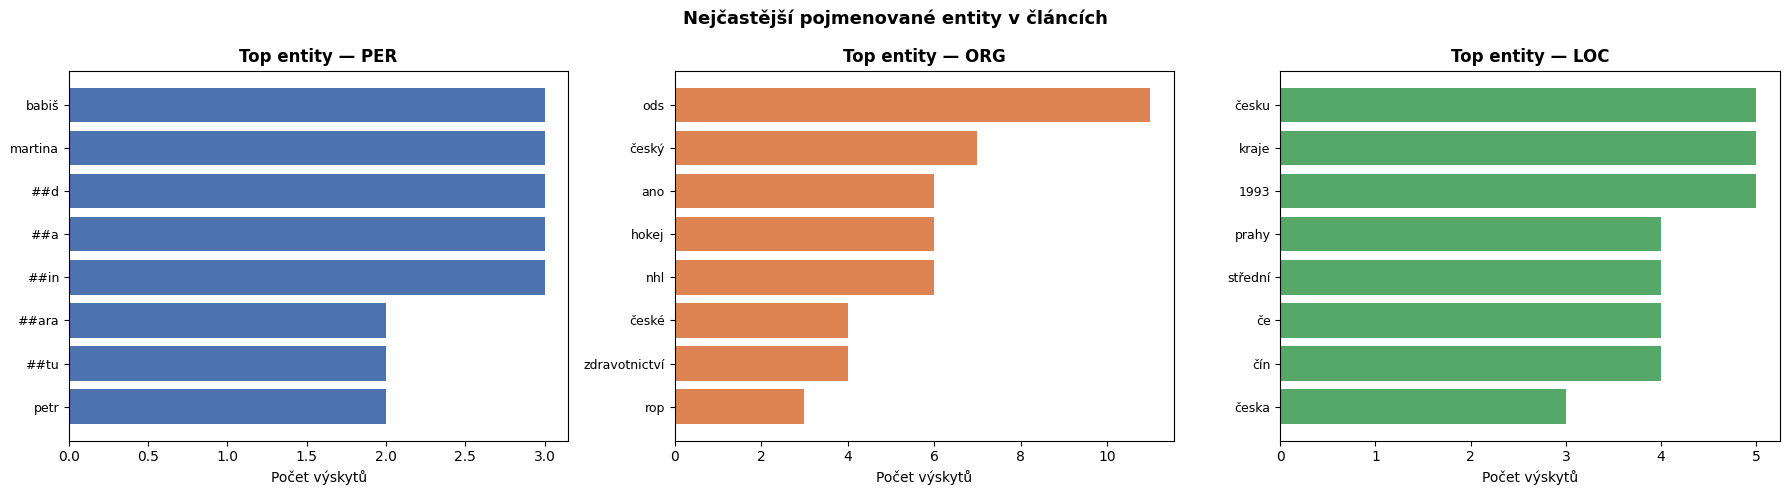

In [ ]:
from transformers import pipeline
from collections import Counter
import matplotlib.pyplot as plt
import pandas as pd

print("Načítám český NER model...")
ner_pipeline = pipeline(
    "ner",
    model="richielo/small-e-czech-finetuned-ner-wikiann",
    aggregation_strategy="simple"
)
print("Model načten.")

def extract_entities(text):
    """Extrahuje pojmenované entity z textu pomocí českého NER modelu."""
    if not text or pd.isna(text):
        return []
    results = ner_pipeline(text[:1500])
    return [
        {'text': r['word'].strip(), 'type': r['entity_group']}
        for r in results if r['word'].strip()
    ]

if 'articles_df' in locals() and not articles_df.empty:
    print(f"Extrahuji entity z {len(articles_df)} článků...")
    articles_df['entities'] = articles_df['text'].apply(extract_entities)
    print("Hotovo.")

    all_ents    = [e for ents in articles_df['entities'] for e in ents]
    ent_counter  = Counter(e['text'] for e in all_ents)
    type_counter = Counter(e['type'] for e in all_ents)

    print(f"\nNalezeno {len(all_ents)} výskytů entit ({len(ent_counter)} unikátních).")
    print("\nRozložení podle typu:")
    for etype, cnt in type_counter.most_common():
        print(f"  {etype:6s}: {cnt}")

    print("\nTop 15 nejčastějších entit:")
    display(pd.DataFrame(ent_counter.most_common(15), columns=['Entita', 'Počet výskytů']))

    target_types = [t for t in ['PER', 'ORG', 'LOC'] if type_counter.get(t, 0) > 0]
    if target_types:
        fig, axes = plt.subplots(1, len(target_types), figsize=(6 * len(target_types), 5))
        if len(target_types) == 1:
            axes = [axes]
        palette = {'PER': '#4C72B0', 'ORG': '#DD8452', 'LOC': '#55A868'}

        for ax, etype in zip(axes, target_types):
            ents_of_type = [e['text'] for e in all_ents if e['type'] == etype]
            top = Counter(ents_of_type).most_common(8)
            if not top:
                ax.set_visible(False)
                continue
            labels, vals = zip(*top)
            ax.barh(list(labels)[::-1], list(vals)[::-1], color=palette.get(etype, '#999'))
            ax.set_title(f"Top entity — {etype}", fontweight='bold')
            ax.set_xlabel("Počet výskytů")
            ax.tick_params(axis='y', labelsize=9)

        plt.suptitle("Nejčastější pojmenované entity v článcích", fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.show()
    else:
        print("Žádné entity typu PER/ORG/LOC nebyly nalezeny.")
else:
    print("articles_df neexistuje nebo je prázdný.")

---

## 5a. Vlastní index subjektivity

Tohle byl náš původní nápad ještě před tím, než jsme sáhli po BERT modelu: čistě lingvistický přístup bez jakéhokoliv předtrénovaného modelu.

Logika je přímočará: **novinář, který chce být objektivní, bude popisovat fakta** (podstatná jména, slovesa). **Novinář, který do textu vnáší vlastní názor, bude text „barvit"** a k tomu používá přídavná jména a příslovce. Takže stačí spočítat poměr:

> **Index = (přídavná jména + příslovce) / (podstatná jména + slovesa)**

Jednoduchý, interpretovatelný, bez závislosti na externím modelu. Nevýhoda je, že nerozlišuje kontext — negativní a pozitivní přídavné jméno váží stejně. Proto jsme ho pak vylepšili přes Word2Vec (sekce 7).

In [ ]:
def calculate_subjectivity_index(pos_tags):
    """Vypočítá index subjektivity na základě poměru slovních druhů."""
    if not pos_tags:
        return 0.0

    counts = {'ADJ': 0, 'ADV': 0, 'NOUN': 0, 'VERB': 0}

    for word, tag in pos_tags:
        if tag in counts:
            counts[tag] += 1

    # Jmenovatel (fakta): Podstatná jména + Slovesa
    factual_base = counts['NOUN'] + counts['VERB']
    # Čitatel (emoce/popis): Přídavná jména + Příslovce
    descriptive_part = counts['ADJ'] + counts['ADV']

    if factual_base == 0:
        return 0.0

    # Výpočet indexu
    index = descriptive_part / factual_base
    return round(index, 4)

if 'articles_df' in locals() and 'pos_tags' in articles_df.columns:
    articles_df['subjectivity_index'] = articles_df['pos_tags'].apply(calculate_subjectivity_index)

    print("Index subjektivity vypočítán. Zde jsou výsledky (čím vyšší číslo, tím subjektivnější styl):")
    # Seřadíme od nejvíce subjektivních
    display(articles_df[['title', 'subjectivity_index']].sort_values(by='subjectivity_index', ascending=False).head(10))
else:
    print("Chybí data z POS taggingu pro výpočet indexu.")

Index subjektivity vypočítán. Zde jsou výsledky (čím vyšší číslo, tím subjektivnější styl):


,title,subjectivity_index
8,Proočkovanost proti covidu se dramaticky propa...,0.6364
7,"Jeden z Babišovy party padl, druhý přichází. Č...",0.6169
42,Případ ukradené relikvie a co zdražuje život Č...,0.6000
40,Zbylá část „Bradavic“ na Pražském hradě dostan...,0.5275
25,Vizita: Co chce Vojtěch za třicet miliard? Vel...,0.5237
51,Nejlepší recept na palačinky plněné tvarohovým...,0.5172
17,Policie odložila trestní oznámení na Trikoloru...,0.5161
5,První malý modulární reaktor v Česku může být ...,0.4779
39,50 let Majora Zemana. Seriál sledovalo 90 proc...,0.4753
46,Diamant za čtvrt miliardy v aukci. Jde o nejvě...,0.4731


## 5b. Analýza sentimentu pomocí BERT

Vlastní index je pěkný, ale zajímalo nás, jak by dopadl výsledek kdyby jsme místo počítání slovních druhů použili něco mocnějšího. Z cvičení jsme znali Hugging Face, takže jsme sáhli po vícejazyčném BERT modelu `nlptown/bert-base-multilingual-uncased-sentiment`.

Model hodnotí text na škále **1–5 hvězdiček** (1 = velmi negativní tón, 5 = velmi pozitivní). My z toho ještě dopočítáváme `bias_magnitude`:
- absolutní odchylka od neutrální hodnoty 3, takže čím víc se text přiklání k oběma pólům, tím vyšší zaujatost.

Praktický problém byl, že BERT má limit ~512 tokenů. Řešili jsme to **chunkingem** neboli tím že dlouhý článek rozdělíme na části, každou vyhodnotíme zvlášť a výsledky průměrujeme. Bez toho by se analyzovala jen první strana článku.

In [ ]:
from transformers import pipeline
import pandas as pd
import os

try:
    # Načtení tokenu z prostředí (místo Colab Secrets)
    hf_token = os.environ.get('HF_TOKEN')

    # Načtení vícejazyčného modelu pro analýzu sentimentu s použitím tokenu
    sentiment_pipeline = pipeline(
        "sentiment-analysis",
        model="nlptown/bert-base-multilingual-uncased-sentiment",
        token=hf_token
    )

    def analyze_bias(text):
        """Analyzuje sentiment textu pomocí BERT modelu.
        BERT má limit ~512 tokenů (~1500 znaků). Delší texty rozdělíme na chunky
        a výsledný sentiment určíme průměrem skóre přes všechny části článku.
        """
        CHUNK_SIZE = 1500
        chunks = [text[i:i + CHUNK_SIZE] for i in range(0, min(len(text), 6000), CHUNK_SIZE)]
        labels, scores = [], []
        try:
            for chunk in chunks:
                r = sentiment_pipeline(chunk)[0]
                labels.append(int(r['label'].split()[0]))
                scores.append(r['score'])
            avg_label = round(sum(labels) / len(labels))
            avg_score = round(sum(scores) / len(scores), 4)
            return f"{avg_label} star{'s' if avg_label != 1 else ''}", avg_score
        except Exception:
            return "Error", 0.0

    if 'articles_df' in locals() and not articles_df.empty:
        print("Provádím analýzu sentimentu článků pomocí vícejazyčného modelu...")
        results = articles_df['text'].apply(analyze_bias).tolist()
        articles_df[['sentiment_label', 'sentiment_score']] = pd.DataFrame(results, index=articles_df.index)

        # Přidání sloupce pro numerické skóre sentimentu
        articles_df['sentiment_numeric'] = articles_df['sentiment_label'].apply(lambda x: int(x.split(' ')[0]))
        # Výpočet "zaujatosti" jako absolutní odchylky od neutrální hodnoty 3
        articles_df['bias_magnitude'] = abs(articles_df['sentiment_numeric'] - 3)

        print("Analýza dokončena. Výsledky (1-5 hvězdiček, seřazeno podle zaujatosti):")
        display(articles_df[['title', 'sentiment_label', 'sentiment_score', 'bias_magnitude']]
                .sort_values(by='bias_magnitude', ascending=False).head(10))
    else:
        print("Dataframe 'articles_df' neexistuje.")
except Exception as e:
    print(f"Došlo k chybě při inicializaci modelu: {e}")
    print("Pokud chcete použít HuggingFace model, nastavte proměnnou prostředí HF_TOKEN.")

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 8357.26it/s]


Provádím analýzu sentimentu článků pomocí vícejazyčného modelu...
Analýza dokončena. Výsledky (1-5 hvězdiček, seřazeno podle zaujatosti):


,title,sentiment_label,sentiment_score,bias_magnitude
56,"Superdávka: Podmínky, majetkový test a kalkulačka",1 star,0.4556,2
10,"Měli bychom změnit zákon, aby na dotace měl ná...",1 star,0.4463,2
30,Sponzor vyhodil trenéra. Nejmenší účastník MS ...,1 star,0.4153,2
24,"Trump se v Pekingu dostal do pozice, na kterou...",5 stars,0.2741,2
34,Je to moje chyba. Vyzval jsem lidi příliš brzy...,1 star,0.3840,2
35,Jak před spaním vypnout hlavu? Začněte už přes...,1 star,0.5142,2
19,"Kauza Motol: Policie nově stíhá firmu, která s...",1 star,0.4415,2
17,Policie odložila trestní oznámení na Trikoloru...,1 star,0.6432,2
47,Kdy budou volby v ČR? Seznam voleb 2026-2040,1 star,0.4274,2
11,"Střízlivá Sněmovna. Je tu návrh, aby poslanci ...",1 star,0.4480,2


### 5c. TF-IDF — O čem konkrétně každý článek je

TF-IDF jsme přidali primárně proto, aby interaktivní graf v sekci 10 byl užitečnější. Při najetí myší na bod chceme vidět nejen titulek, ale i klíčová slova článku.

Zároveň nás ale zajímalo, jaká slova jsou charakteristická pro každý článek v kontextu celého korpusu. **TF-IDF tohle řeší:** slovo, které je v článku časté, ale zároveň se moc nevyskytuje jinde, dostane vysoké skóre. Obecné výrazy jako „česká republika" jsou sice časté, ale jsou všude, takže je TF-IDF přirozeně potlačí.

Použili jsme bigramy (dvojice slov) navíc k unigramům — zachytí to fráze jako „ministerstvo financí" nebo „česká vláda" lépe než jednotlivá slova.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

if 'articles_df' in locals() and 'lemmatized_text' in articles_df.columns:
    # TF-IDF nad lematizovanými texty (bez stop slov — ta byla odstraněna v sekci 3)
    tfidf = TfidfVectorizer(
        max_features=500,       # slovník omezíme na 500 nejdůležitějších slov
        ngram_range=(1, 2),     # unigramy i bigramy (dvojice slov)
        min_df=2,               # slovo musí být alespoň ve 2 článcích
        sublinear_tf=True,      # log-škálování TF (potlačí dominanci velmi častých slov)
    )

    tfidf_matrix = tfidf.fit_transform(articles_df['lemmatized_text'].fillna(''))
    feature_names = tfidf.get_feature_names_out()

    def get_top_keywords(row_idx, n=6):
        row = tfidf_matrix[row_idx]
        scores = zip(feature_names, row.toarray()[0])
        sorted_scores = sorted(scores, key=lambda x: x[1], reverse=True)
        return ', '.join(w for w, s in sorted_scores[:n] if s > 0)

    articles_df['top_keywords'] = [get_top_keywords(i) for i in range(len(articles_df))]

    print("TF-IDF klíčová slova extrahována. Ukázka pro prvních 5 článků:")
    display(articles_df[['title', 'top_keywords']].head())

    # --- Globální přehled: která slova jsou nejdůležitější napříč celým korpusem ---
    import numpy as np
    global_tfidf_scores = tfidf_matrix.sum(axis=0).A1
    top_global_idx = global_tfidf_scores.argsort()[-20:][::-1]
    top_global = [(feature_names[i], round(global_tfidf_scores[i], 3)) for i in top_global_idx]

    print("\nTop 20 slov napříč celým korpusem (součet TF-IDF skóre):")
    global_df = pd.DataFrame(top_global, columns=['Slovo / Bigram', 'TF-IDF skóre'])
    display(global_df)
else:
    print("Chybí articles_df nebo sloupec 'lemmatized_text'. Spusťte nejprve sekci 4.")

TF-IDF klíčová slova extrahována. Ukázka pro prvních 5 článků:


,title,top_keywords
0,"Berou sto tisíc, je jim přes 30 a žijí ve spol...","byt, bydlení, investor, tisíc koruna, příjem, ..."
1,Kdy jsou opravdu potřeba antibiotika a jak pře...,"lékař, pacient, často, potřeba, podcast, oko"
2,Schillerové protiinflační dluhopisy se vrací,"tři, státní, měsíc, ministerstvo, procento, pět"
3,V Havaně lidé protestovali kvůli nedostatku el...,"kuba, ministr, řada, žádný, mít, ostrov"
4,Trenér Koubek nesouhlasí s vyřazením Chorého a...,"hráč, oko, slavium, názor, david, oba"



Top 20 slov napříč celým korpusem (součet TF-IDF skóre):


,Slovo / Bigram,TF-IDF skóre
0,být,3.065
1,léta,2.957
2,český,2.650
3,rok,2.619
4,velký,2.485
5,jeden,2.317
6,všechen,2.179
7,on,2.150
8,den,2.077
9,lepší,1.981


### 5d. Wordcloud

Přidali jsme wordcloud hlavně proto, že v prezentaci okamžitě lze vidět o čem korpus pojednává.

Velikost každého slova odpovídá jeho TF-IDF skóre. Čím větší slovo, tím charakterističtější pro daný korpus. Pokud máme data z více médií (sekce 8), vygenerujeme wordcloud zvlášť pro každý zdroj, snadno pak vidíme, jestli se témata různých redakcí liší.

In [ ]:
# Instalace wordcloud pokud chybí
try:
    from wordcloud import WordCloud
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'wordcloud', '-q'])
    from wordcloud import WordCloud

import matplotlib.pyplot as plt
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

def generate_wordcloud(texts, title, ax, colormap='viridis'):
    """Vygeneruje wordcloud z listu textů pomocí TF-IDF vah."""
    if not texts:
        ax.set_visible(False)
        return
    vec = TfidfVectorizer(max_features=200, ngram_range=(1, 1), sublinear_tf=True)
    try:
        matrix = vec.fit_transform(texts)
    except ValueError:
        ax.set_visible(False)
        return
    scores = matrix.sum(axis=0).A1
    word_scores = dict(zip(vec.get_feature_names_out(), scores))
    wc = WordCloud(
        width=800, height=400,
        background_color='white',
        colormap=colormap,
        max_words=80,
        prefer_horizontal=0.8,
    ).generate_from_frequencies(word_scores)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.axis('off')

if 'articles_df' in locals() and 'lemmatized_text' in articles_df.columns:
    texts_all = articles_df['lemmatized_text'].fillna('').tolist()

    # Zjistíme zda máme multi-source data
    has_source = 'source' in articles_df.columns
    sources = articles_df['source'].unique().tolist() if has_source else []

    if has_source and len(sources) > 1:
        # Grid: 1 celkový + per médium
        n_cols = min(3, len(sources) + 1)
        n_rows = ((len(sources) + 1) + n_cols - 1) // n_cols
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
        axes = np.array(axes).flatten()

        cmaps = ['viridis', 'plasma', 'inferno', 'magma', 'cividis', 'cool', 'hot']
        generate_wordcloud(texts_all, "🌍 Všechny zdroje celkem", axes[0], cmaps[0])
        for idx, (src, cmap) in enumerate(zip(sources, cmaps[1:]), start=1):
            src_texts = articles_df[articles_df['source'] == src]['lemmatized_text'].fillna('').tolist()
            generate_wordcloud(src_texts, f"📰 {src}", axes[idx], cmap)
        for ax in axes[len(sources) + 1:]:
            ax.set_visible(False)
    else:
        fig, ax = plt.subplots(figsize=(12, 5))
        generate_wordcloud(texts_all, "Wordcloud — klíčová slova celého korpusu", ax)

    plt.suptitle("Wordcloud: nejdůležitější slova dle TF-IDF", fontsize=15, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print("Chybí lemmatized_text. Spusťte nejprve sekci 4.")

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try brew install
    xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a Python library that isn't in Homebrew,
    use a virtual environment:
    
    python3 -m venv path/to/venv
    source path/to/venv/bin/activate
    python3 -m pip install xyz
    
    If you wish to install a Python application that isn't in Homebrew,
    it may be easiest to use 'pipx install xyz', which will manage a
    virtual environment for you. You can install pipx with
    
    brew install pipx
    
    You may restore the old behavior of pip by passing
    the '--break-system-packages' flag to pip, or by adding
    'break-system-packages = true' to your pip.conf file. The latter
    will permanently disable this error.
    
    If you disable this error, we STRONGLY recommend that you additionally
    pass the '--user' flag to pip, or set 

CalledProcessError: Command '['/opt/homebrew/opt/python@3.13/bin/python3.13', '-m', 'pip', 'install', 'wordcloud', '-q']' returned non-zero exit status 1.

---

---
# Optimalizace

V předchozích sekcích jsme ukázali základ, jednoduchý index subjektivity plus BERT sentiment. Oba přístupy mají ale slabiny: vlastní index ignoruje kontext slov, BERT zase nedokáže rozlišit, jestli je subjektivita způsobena negativním tónem nebo jen expresivním stylem.

V této části zkoušíme věc opravit trénováním Word2Vec modelu na našem vlastním korpusu a LDA topic modelingem jako dalším úhlem pohledu.

### 6. Word2Vec - Sémantický model natrénovaný na našich datech

Základní problém vlastního indexu je, že přídavné jméno „státní" (objektivní popis) a „skandální" (silné zabarvení) váží stejně. Word2Vec tohle dokáže rozlišit. Každé slovo reprezentuje jako vektor v prostoru, kde **sémanticky blízká slova jsou si geometricky blízko**.

Natrénujeme model přímo na našem lemmatizovaném korpusu. Je sice malý, ale je to náš corpus z novin, takže sémantické vztahy by měly odpovídat zpravodajskému stylu lépe než obecné předtrénované modely.

In [ ]:
# Instalace knihovny gensim, pokud ještě není
!pip install gensim --quiet

In [ ]:
from gensim.models import Word2Vec

if 'articles_df' in locals() and not articles_df.empty and 'lemmatized_text' in articles_df.columns:
    print("Trénuji Word2Vec model na lematizovaných textech...")
    # Připravíme data pro Word2Vec (seznam vět, kde každá věta je seznam slov)
    sentences = [text.split() for text in articles_df['lemmatized_text'] if isinstance(text, str) and text]

    # Upozornění při malém korpusu — Word2Vec potřebuje dostatek dat pro smysluplné vektory
    if len(sentences) < 50:
        print(f"⚠️  Upozornění: korpus obsahuje pouze {len(sentences)} článků. "
              "Pro spolehlivé Word2Vec vektory doporučujeme alespoň 50 článků "
              "(zvyšte num_articles_to_download nebo použijte multi-source data ze sekce 8).")

    # Trénujeme Word2Vec model
    # vector_size: dimenze vektorů (velikost vektorového prostoru)
    # window: maximální vzdálenost mezi aktuálním a predikovaným slovem ve větě
    # min_count=1: zahrnout všechna slova (při malém korpusu); při >200 článcích zvyšte na 2-3
    # workers: počet jader procesoru pro trénování (pro zrychlení)
    w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=1, workers=4, seed=42)
    print(f"Word2Vec model natrénován na slovníku o velikosti: {len(w2v_model.wv)} slov.")
else:
    print("DataFrame 'articles_df' neexistuje, je prázdný nebo chybí sloupec 'lemmatized_text'.")

Trénuji Word2Vec model na lematizovaných textech...
Word2Vec model natrénován na slovníku o velikosti: 6261 slov.


### 7. Sémantická polarizace přídavných jmen (Word2Vec)

Jakmile máme Word2Vec model, dokážeme pro každé přídavné jméno změřit, jak moc je „blízko" subjektivním slovům (jako *skandální, skvělý, hrozný*) oproti objektivním slovům (jako *státní, finanční, mezinárodní*).

Z toho počítáme tři metriky, kde každá je sofistikovanější než předchozí:
- **subjectivity_index** — náš původní jednoduchý poměr slovních druhů
- **adj_polarization_score** — jak moc se přídavná jména v článku přiklánějí k subjektivním kotvám (0 = objektivní, 1 = subjektivní)
- **refined_bias_score** — kombinace obou výše — vyřeší problém, kdy krátký článek s jedním silným přídavným jménem a dlouhý neutrální článek vycházely podobně

In [ ]:
import numpy as np

def get_adjective_sentiment_refined(w2v_model, adjectives):
    """Vypočítá sémantickou polaritu přídavných jmen vůči kotevním slovům s ošetřením záporných hodnot."""
    anchors_sub = [
        'lepší', 'vlastní', 'nutné', 'poslední', 'aktuální', 'rád', 'špatný', 'dobrý',
        'neuvěřitelný', 'kontroverzní', 'skvělý', 'hrozný', 'důležitý', 'zajímavý', 'překvapivý', 'jasný'
    ]
    anchors_obj = [
        'české', 'vládní', 'státní', 'evropské', 'ekonomické', 'členské', 'pražský',
        'místní', 'finanční', 'tiskový', 'pracovní', 'zahraniční', 'vojenský', 'veřejný', 'politický'
    ]

    valid_sub = [w for w in anchors_sub if w in w2v_model.wv]
    valid_obj = [w for w in anchors_obj if w in w2v_model.wv]

    if not valid_sub or not valid_obj:
        return 0.5

    scores = []
    for adj in adjectives:
        if adj in w2v_model.wv:
            # Průměrná podobnost (ošetříme záporné hodnoty na 0)
            sim_sub = max(0, np.mean([w2v_model.wv.similarity(adj, s) for s in valid_sub]))
            sim_obj = max(0, np.mean([w2v_model.wv.similarity(adj, o) for o in valid_obj]))

            # Normalizace: podíl subjektivity na celkové podobnosti
            total_sim = sim_sub + sim_obj
            if total_sim > 0:
                adj_score = sim_sub / total_sim
                scores.append(adj_score)

    return round(sum(scores) / len(scores), 4) if scores else 0.5

if 'articles_df' in locals() and 'w2v_model' in locals():
    print("Přepočítávám stabilizovanou sémantickou polarizaci (rozsah 0-1)...")

    articles_df['adj_polarization_score'] = articles_df['adjectives_only'].apply(
        lambda x: get_adjective_sentiment_refined(w2v_model, x)
    )

    articles_df['refined_bias_score'] = (
        articles_df['subjectivity_index'] *
        articles_df['adj_polarization_score'] * 10
    ).round(4)

    display(articles_df[['title', 'subjectivity_index', 'adj_polarization_score', 'refined_bias_score']]
            .sort_values(by='refined_bias_score', ascending=False).head(10))
else:
    print("Chybí articles_df nebo w2v_model.")

Přepočítávám stabilizovanou sémantickou polarizaci (rozsah 0-1)...


,title,subjectivity_index,adj_polarization_score,refined_bias_score
51,Nejlepší recept na palačinky plněné tvarohovým...,0.5172,0.6076,3.1425
26,"Marie April: Zpívám o věcech, které jsou nepří...",0.8889,0.3534,3.1414
46,Češi jako milovníci kol. Platí za ně horentní ...,0.4844,0.5748,2.7843
5,Fico versus Magyar. O co jde u Benešových dekr...,0.4904,0.5569,2.7310
45,Šťastné pondělí: Kavčí hory na prodej. Destruk...,0.4545,0.5807,2.6393
33,České děti rekordně málo spí. Navíc jim škodí ...,0.4826,0.5412,2.6118
36,Dentální hygiena může ušetřit tisíce. Mezizubn...,0.5000,0.4962,2.4810
10,"Německý kancléř hledá dno, už je z něj nejméně...",0.5000,0.4824,2.4120
40,Byla ve stylu amerických mrakodrapů. Teď budov...,0.4400,0.5382,2.3681
56,"Dvorecký most: Mapa, jak most změní trasy MHD",0.3786,0.6150,2.3284


### 8. LDA — Jaká témata v korpusu dominují

TF-IDF ukáže klíčová slova jednotlivých článků, ale nezodpoví otázku: **existují v korpusu opakující se tematické vzory?** K tomu slouží LDA (Latent Dirichlet Allocation).

LDA předpokládá, že každý článek je složen z několika latentních témat a každé téma je charakterizováno skupinou slov. Model tato témata sám odhalí a my jen určíme kolik jich chceme.

Pro nás to bylo zajímavé ze dvou důvodů: jednak jako způsob jak vizualizovat, o čem různá média píšou, a jednak jestli rozdíly v subjektivitě mezi médii nesouvisí náhodou s tím, že různá média pokrývají různá témata (a o sportu se píše jinak než o politice).

Používám multi-source data: 169 článků
Trénuji LDA model (6 témat, slovník 4030 slov)...
Hotovo.


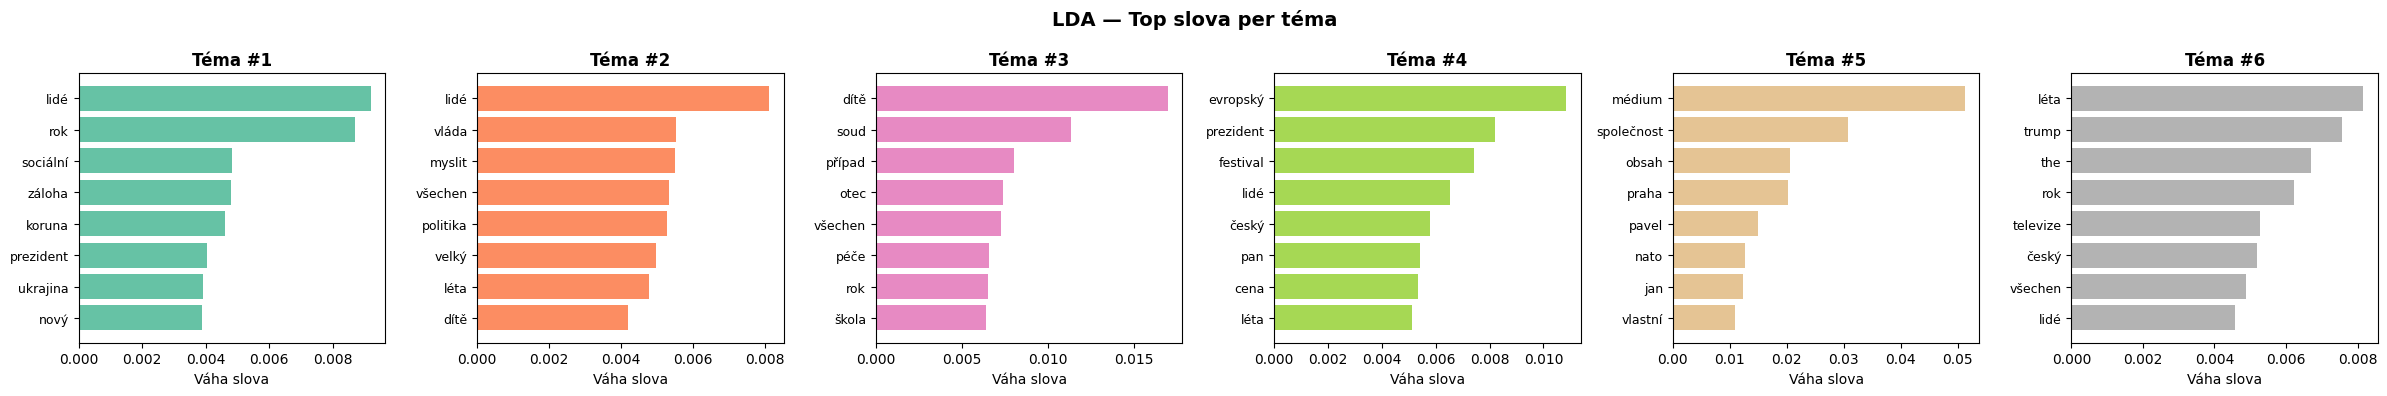


Přiřazení témat článkům (ukázka):


,title,dominant_topic,topic_label
0,Nová rubrika Zdraví+ na Seznamu startuje! Pomů...,2,lidé / vláda / myslit
1,"Peklo s Baníkem. Chtěl být v Evropě, místo toh...",3,dítě / soud / případ
2,"Tisíce korun pro lidi. Vojtěch navrhne, aby po...",1,lidé / rok / sociální
3,Soud zamítl žalobu otce oběti střelby na FF UK...,1,lidé / rok / sociální
4,Fico versus Magyar. O co jde u Benešových dekr...,1,lidé / rok / sociální
5,Bude víc povolenek zdarma. Babišovi spadl do k...,4,evropský / prezident / festival
6,Putin zakazuje „ty internety“. Rusům krade moz...,3,dítě / soud / případ
7,"Říkal jsem si: je to mstivý člověk, popisuje e...",2,lidé / vláda / myslit
8,"Kdyby soud rozhodl jinak, holčička žije, říká ...",3,dítě / soud / případ
9,"Německý kancléř hledá dno, už je z něj nejméně...",1,lidé / rok / sociální


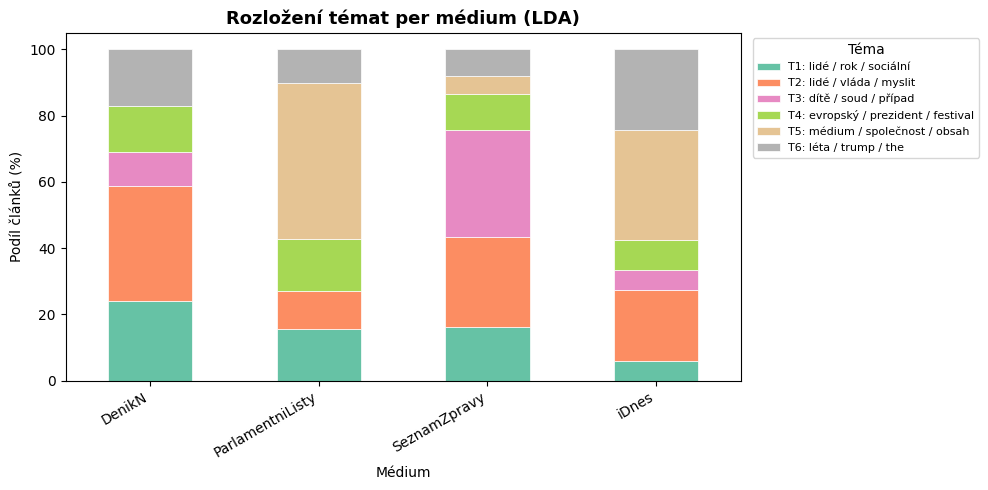

In [ ]:
from gensim import corpora
from gensim.models import LdaModel
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Volba DataFrame — preferujeme multi-source, fallback na single-source
if 'all_outlets_df' in locals() and 'lemmatized_text' in all_outlets_df.columns:
    df_lda = all_outlets_df.copy()
    print(f"Používám multi-source data: {len(df_lda)} článků")
elif 'articles_df' in locals() and 'lemmatized_text' in articles_df.columns:
    df_lda = articles_df.copy()
    print(f"Používám single-source data: {len(df_lda)} článků")
else:
    df_lda = None
    print("Chybí lemmatized_text. Spusťte nejprve sekci 4.")

if df_lda is not None:
    NUM_TOPICS = 6
    NUM_WORDS  = 8

    # Tokenizace + post-lemmatizační filtr:
    # stop slova a krátká slova odstraníme znovu, protože lemmatizace může
    # odhalit základní tvary (mít, moci, stát…) které v surové formě projdou
    texts = [
        [w for w in t.split() if w not in czech_stop_words and len(w) >= 3]
        for t in df_lda['lemmatized_text'].fillna('') if t
    ]
    dictionary = corpora.Dictionary(texts)
    dictionary.filter_extremes(no_below=2, no_above=0.9)
    corpus = [dictionary.doc2bow(t) for t in texts]

    print(f"Trénuji LDA model ({NUM_TOPICS} témat, slovník {len(dictionary)} slov)...")
    lda_model = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=NUM_TOPICS,
        passes=20,
        alpha='auto',
        eta='auto',
        random_state=42,
    )
    print("Hotovo.")

    # --- Vizualizace: top slova per téma ---
    fig, axes = plt.subplots(1, NUM_TOPICS, figsize=(4 * NUM_TOPICS, 4))
    colors = plt.cm.Set2(np.linspace(0, 1, NUM_TOPICS))

    for topic_idx, ax in enumerate(axes):
        top_words = lda_model.show_topic(topic_idx, topn=NUM_WORDS)
        words, weights = zip(*top_words)
        ax.barh(list(words)[::-1], list(weights)[::-1], color=colors[topic_idx])
        ax.set_title(f"Téma #{topic_idx + 1}", fontweight='bold')
        ax.set_xlabel("Váha slova")
        ax.tick_params(axis='y', labelsize=9)

    plt.suptitle("LDA — Top slova per téma", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # --- Přiřazení dominantního tématu každému článku ---
    def get_dominant_topic(bow):
        topics = lda_model.get_document_topics(bow, minimum_probability=0)
        return max(topics, key=lambda x: x[1])[0] + 1  # 1-indexed

    df_lda['dominant_topic'] = [get_dominant_topic(c) for c in corpus]

    topic_labels = {
        i + 1: ' / '.join(w for w, _ in lda_model.show_topic(i, topn=3))
        for i in range(NUM_TOPICS)
    }
    df_lda['topic_label'] = df_lda['dominant_topic'].map(topic_labels)

    print("\nPřiřazení témat článkům (ukázka):")
    display(df_lda[['title', 'dominant_topic', 'topic_label']].head(10))

    # --- Rozložení témat per médium (pokud máme source sloupec) ---
    if 'source' in df_lda.columns and df_lda['source'].nunique() > 1:
        pivot = df_lda.groupby(['source', 'dominant_topic']).size().unstack(fill_value=0)
        pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

        fig, ax = plt.subplots(figsize=(10, 5))
        pivot_pct.plot(kind='bar', stacked=True, ax=ax,
                       colormap='Set2', edgecolor='white', linewidth=0.5)
        ax.set_ylabel("Podíl článků (%)")
        ax.set_xlabel("Médium")
        ax.set_title("Rozložení témat per médium (LDA)", fontsize=13, fontweight='bold')
        ax.legend(
            title="Téma",
            labels=[f"T{i}: {topic_labels[i]}" for i in sorted(topic_labels)],
            bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8
        )
        plt.xticks(rotation=30, ha='right')
        plt.tight_layout()
        plt.show()

    if 'articles_df' in locals():
        articles_df = articles_df.merge(
            df_lda[['url', 'dominant_topic', 'topic_label']],
            on='url', how='left'
        ) if 'url' in articles_df.columns else articles_df

---
## 8. Srovnávací analýza napříč mediálními zdroji

Dosud jsme pracovali jen se SeznamZprávami — to je fajn pro vývoj metod, ale samo o sobě to není moc zajímavý výsledek. Zajímavější otázka je: **liší se různá česká média v míře subjektivity, a pokud ano — statisticky prokazatelně?**

Rozhodli jsme se porovnat několik redakcí s různým politickým profilem a cílovou skupinou. Záměrně jsme zařadili média, u kterých bychom intuitivně čekali rozdíly — a chtěli jsme vidět, zda to naše metody také zachytí.

**Porovnávané zdroje:**
- **SeznamZprávy** — již staženo výše, nejde stahovat znovu
- **iDnes.cz** — velké mainstreamové médium
- **Deník N** — investigativní, analytický styl
- **Parlamentní listy** — výrazně názorový profil

In [ ]:
import re

# Registr zpravodajských serverů s jejich URL filtry
OUTLET_REGISTRY = [
    {
        'source_name': 'SeznamZpravy',
        'already_downloaded': True,  # Použijeme již stažené articles_df
    },
    {
        'base_url': 'https://www.idnes.cz/',
        'source_name': 'iDnes',
        'url_filter': lambda url: bool(re.search(
            r'idnes\.cz/(zpravy|ekonomika|sport|domaci|zahranicni|kultura)/', url
        )),
        'num_articles': 120,
    },
    {
        'base_url': 'https://denikn.cz/',
        'source_name': 'DenikN',
        'url_filter': lambda url: bool(re.match(r'https?://denikn\.cz/\d+/', url)),
        'num_articles': 120,
    },
    {
        'base_url': 'https://www.parlamentnilisty.cz/',
        'source_name': 'ParlamentniListy',
        'url_filter': lambda url: bool(re.search(
            r'parlamentnilisty\.cz/(arena|politika|zpravy|profily)/', url
        )),
        'num_articles': 70,
    },
]


def scrape_outlet(base_url, url_filter, num_articles, source_name):
    """
    Generalizovaný scraper pro libovolný zpravodajský server.
    Přijímá funkci url_filter místo pevně zakódovaného řetězce '/clanek/'.
    Vrací seznam slovníků se stejnými klíči jako get_articles_from_url,
    navíc obsahuje klíč 'source'.
    """
    config = Config()
    config.browser_user_agent = 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/119.0.0.0 Safari/537.36'
    config.request_timeout = 30

    print(f"[{source_name}] Stahuji z: {base_url}")
    try:
        paper = build(base_url, config=config, memoize_articles=False)
        print(f"[{source_name}] Nalezeno {len(paper.articles)} potenciálních článků.")
    except Exception as e:
        print(f"[{source_name}] CHYBA při budování zdroje: {e}")
        return []

    candidates = [a for a in paper.articles if url_filter(a.url)]
    print(f"[{source_name}] Po filtrování: {len(candidates)} kandidátů.")

    articles_data = []
    for i, article_obj in enumerate(candidates):
        if i >= num_articles:
            break
        try:
            article = Article(article_obj.url, config=config)
            article.download()
            article.parse()

            soup = None
            if article.html:
                soup = BeautifulSoup(article.html, 'lxml')

            # --- EXTRAKCE TITULKU ---
            if not article.title and soup:
                og_title = soup.find('meta', property='og:title')
                if og_title and og_title.get('content'):
                    article.title = og_title['content'].strip()
                elif soup.title:
                    article.title = soup.title.get_text(strip=True)
                else:
                    h1_tag = soup.find('h1')
                    if h1_tag:
                        article.title = h1_tag.get_text(strip=True)

            # --- EXTRAKCE AUTORA A DATA PUBLIKACE (JSON-LD) ---
            authors_list = article.authors
            publish_date = None

            if soup:
                for script in soup.find_all('script', type='application/ld+json'):
                    try:
                        data = json.loads(script.string)
                        if isinstance(data, list):
                            data = data[0]
                        if isinstance(data, dict) and data.get('@type') in ['NewsArticle', 'Article', 'ReportageNewsArticle']:
                            if not publish_date and data.get('datePublished'):
                                publish_date = data.get('datePublished')
                            if not authors_list:
                                author_data = data.get('author')
                                if isinstance(author_data, list):
                                    authors_list = [a.get('name') for a in author_data if isinstance(a, dict) and a.get('name')]
                                elif isinstance(author_data, dict) and author_data.get('name'):
                                    authors_list = [author_data.get('name')]
                    except (json.JSONDecodeError, TypeError, AttributeError):
                        continue

            # --- ZÁLOŽNÍ EXTRAKCE DATA (Meta tagy) ---
            if not publish_date and soup:
                meta_time = soup.find('meta', property='article:published_time')
                if meta_time and meta_time.get('content'):
                    publish_date = meta_time['content'].strip()
                else:
                    meta_date = soup.find('meta', attrs={'itemprop': 'datePublished'})
                    if meta_date and meta_date.get('content'):
                        publish_date = meta_date['content'].strip()
            if not publish_date and article.publish_date:
                publish_date = article.publish_date.strftime('%Y-%m-%dT%H:%M:%S')

            # --- ZÁLOŽNÍ EXTRAKCE AUTORA (Meta tag) ---
            if not authors_list and soup:
                meta_author = soup.find('meta', attrs={'name': 'author'})
                if meta_author and meta_author.get('content'):
                    authors_list = [meta_author['content'].strip()]

            # --- UKLÁDÁNÍ VÝSLEDKŮ ---
            if article.text and article.title:
                articles_data.append({
                    'url': article.url,
                    'title': article.title,
                    'authors': authors_list,
                    'publish_date': publish_date,
                    'text': article.text,
                    'source': source_name,
                })
                print(f"[{source_name}] Stažen {i+1}: {article.title[:60]}")
            else:
                print(f"[{source_name}] Přeskočen {article_obj.url} (chybí text nebo titulek).")

        except Exception as e:
            print(f"[{source_name}] CHYBA u {article_obj.url}: {e}")
            continue

    print(f"[{source_name}] Úspěšně staženo: {len(articles_data)} článků.")
    return articles_data


print("Funkce scrape_outlet a OUTLET_REGISTRY připraveny.")

Funkce scrape_outlet a OUTLET_REGISTRY připraveny.


In [ ]:
import pandas as pd

outlet_dfs = []

# SeznamZpravy: použijeme již stažená data
if 'articles_df' in locals() and not articles_df.empty:
    sz_df = articles_df.copy()
    sz_df['source'] = 'SeznamZpravy'
    outlet_dfs.append(sz_df)
    print(f"SeznamZpravy: použito {len(sz_df)} již stažených článků.")
else:
    print("VAROVÁNÍ: articles_df není k dispozici — SeznamZpravy bude přeskočeno.")

# Stáhneme zbývající servery
for outlet in OUTLET_REGISTRY:
    if outlet.get('already_downloaded'):
        continue
    try:
        raw = scrape_outlet(
            base_url=outlet['base_url'],
            url_filter=outlet['url_filter'],
            num_articles=outlet.get('num_articles', 70),
            source_name=outlet['source_name'],
        )
        if raw:
            outlet_dfs.append(pd.DataFrame(raw))
        else:
            print(f"VAROVÁNÍ: {outlet['source_name']} — staženo 0 článků.")
    except Exception as e:
        print(f"CHYBA při scrapování {outlet['source_name']}: {e}")

# Sestavíme kombinovaný DataFrame
if outlet_dfs:
    all_outlets_df = pd.concat(outlet_dfs, ignore_index=True)
    all_outlets_df.drop_duplicates(subset='url', inplace=True)
    all_outlets_df.reset_index(drop=True, inplace=True)
    print("\nPřehled stažených článků podle zdroje:")
    display(all_outlets_df.groupby('source').size().rename('počet článků').to_frame())
else:
    print("CHYBA: Žádná data nebyla stažena.")

SeznamZpravy: použito 57 již stažených článků.
[iDnes] Stahuji z: https://www.idnes.cz/


CRITICAL:newspaper.network:[REQUEST FAILED] 404 Client Error: Not Found for url: https://www.idnes.cz/feeds
CRITICAL:newspaper.network:[REQUEST FAILED] 404 Client Error: Not Found for url: https://www.idnes.cz/feed


[iDnes] Nalezeno 474 potenciálních článků.
[iDnes] Po filtrování: 93 kandidátů.
[iDnes] Stažen 1: Rusové se na frontě uchylují ke kanibalismu, tvrdí Ukrajinci
[iDnes] Stažen 2: Regulace cen pohonných hmot
[iDnes] Stažen 3: Pálení čarodějnic 2026: Pravidla, zákazy a kdy nahlásit oheň
[iDnes] Stažen 4: Herečka Elle Fanning ukázala prsa v seriálu Margo
[iDnes] Stažen 5: Jaderná havárie v Černobylu. Kde v Česku byla největší radio
[iDnes] Přeskočen https://www.idnes.cz/zpravy/revue/spolecnost/herecka-zpevacka-dagmar-patrasova-narozeniny-70-xenie-zizala.A260427_075749_lidicky_zar (chybí text nebo titulek).
[iDnes] Stažen 7: Jiřina Bohdalová slaví 95 let: jaká byla oslava
[iDnes] Stažen 8: Pepa Kokta v Ornella Life: Ženskou neuhlídáš, říká
[iDnes] Přeskočen https://www.idnes.cz/zpravy/revue/vztahy-a-sex/sandra-novakova-foceni-playboy-manzel-vojtech-moravec.A260420_122048_sex_zar?zdroj=nejnovejsi (chybí text nebo titulek).
[iDnes] Stažen 10: Zuzana Kajnarová: Děti se mnou nemluví, protože mě 

CRITICAL:newspaper.network:[REQUEST FAILED] 404 Client Error:  for url: https://denikn.cz/feeds


[DenikN] Nalezeno 811 potenciálních článků.
[DenikN] Po filtrování: 583 kandidátů.
[DenikN] Přeskočen https://denikn.cz/2047281/vydaje-na-obranu-budou-pod-dvema-procenty-potvrdil-babis-vysvetlujeme-odkud-sva-cisla-vzal/ (chybí text nebo titulek).
[DenikN] Přeskočen https://denikn.cz/2047335/plan-ktery-ma-odstrasit-putina-jak-se-nemecko-pripravuje-na-obranu-pred-ruskem/ (chybí text nebo titulek).
[DenikN] Přeskočen https://denikn.cz/2047091/trumpuv-svet-460-462-den-nejdriv-nechapal-co-se-deje-potom-byl-prezident-nezvykle-mily-co-vime-o-utoku-na-galaveceru/ (chybí text nebo titulek).
[DenikN] Stažen 4: Hranice mezi pragmatismem a hodnotami je jenom sen českých p
[DenikN] Stažen 5: Existuje v kultuře přirozený úspěch? Kauza americké skupiny 
[DenikN] Přeskočen https://denikn.cz/2044656/cesky-ministr-jde-do-boje-za-zemedelske-holdingy-chce-se-vyhnout-skrtum-evropskych-penez-podle-velikosti/ (chybí text nebo titulek).
[DenikN] Přeskočen https://denikn.cz/2042436/vyplati-se-v-dobe-drahych-pa

CRITICAL:newspaper.network:[REQUEST FAILED] 404 Client Error: Not Found for url: https://www.parlamentnilisty.cz/feed
CRITICAL:newspaper.network:[REQUEST FAILED] 404 Client Error: Not Found for url: https://www.parlamentnilisty.cz/feeds


[ParlamentniListy] Nalezeno 111 potenciálních článků.
[ParlamentniListy] Po filtrování: 110 kandidátů.
[ParlamentniListy] Stažen 1: Zapomenutá slova, která „očišťují“ Filipa Turka
[ParlamentniListy] Stažen 2: Džin vypuštěný Petrem Pavlem byl příliš i na jeho zastánce
[ParlamentniListy] Stažen 3: Šimíček: Evropa potřebuje „hodného Trumpa“ a Česko silnou OD
[ParlamentniListy] Stažen 4: Bez Donutila? Ne. Co by bylo s divákem, kdyby zrušili ČT
[ParlamentniListy] Stažen 5: „Fialova politika pokračuje, změny jsou symbolické.“ Mladý h
[ParlamentniListy] Stažen 6: Babiš je lhář, soudem uznaný, opakoval stále Hřib. Pak se po
[ParlamentniListy] Stažen 7: Udivení občané si posílají, co vyrobil Český rozhlas
[ParlamentniListy] Stažen 8: Strach v EU. Trumpova válka otřása „proevropskými“ vládami
[ParlamentniListy] Stažen 9: „A já o vás říkám svým dětem…“ Rajchl a Zdechovský se setkal
[ParlamentniListy] Stažen 10: Fialova ostuda. Na expředsedu ODS udeřilo z nečekané strany
[ParlamentniListy] Stažen 

,počet článků
source,
DenikN,38
ParlamentniListy,70
SeznamZpravy,57
iDnes,57


In [ ]:
if 'all_outlets_df' in locals() and not all_outlets_df.empty:

    print("Krok 1/3: Předzpracování textu...")
    all_outlets_df['cleaned_text'] = all_outlets_df['text'].apply(
        lambda x: preprocess_text(str(x), czech_stop_words)
    )

    print(f"Krok 2/3: POS tagging pomocí Stanza ({len(all_outlets_df)} článků, může trvat déle)...")
    stanza_results = all_outlets_df['cleaned_text'].apply(stanza_process_text)
    all_outlets_df['pos_tags']        = [r[0] for r in stanza_results]
    all_outlets_df['lemmatized_text'] = [r[1] for r in stanza_results]
    all_outlets_df['adjectives_only'] = [r[2] for r in stanza_results]

    print("Krok 3/3: Výpočet indexu subjektivity...")
    all_outlets_df['subjectivity_index'] = all_outlets_df['pos_tags'].apply(
        calculate_subjectivity_index
    )

    print("\nPředzpracování dokončeno. Průměrná subjektivita podle zdroje:")
    display(
        all_outlets_df.groupby('source')['subjectivity_index']
        .mean().round(4).rename('průměrný index subjektivity').to_frame()
    )
else:
    print("all_outlets_df není k dispozici. Spusťte nejprve předchozí buňku.")

Krok 1/3: Předzpracování textu...
Krok 2/3: POS tagging pomocí Stanza (222 článků, může trvat déle)...
Krok 3/3: Výpočet indexu subjektivity...

Předzpracování dokončeno. Průměrná subjektivita podle zdroje:


,průměrný index subjektivity
source,
DenikN,0.3656
ParlamentniListy,0.4012
SeznamZpravy,0.3773
iDnes,0.3600


In [ ]:
from collections import Counter
from gensim.models import Word2Vec
import numpy as np

def get_adjective_sentiment_dynamic(w2v_model, adjectives, common_adj_list):
    """Vylepšený výpočet s dynamickými kotvami z korpusu."""
    # Definice klíčových slov pro dynamické rozdělení kotev
    anchors_obj = [word for word, count in common_adj_list if any(x in word for x in ['česk', 'vlád', 'stát', 'evrop', 'ekonom', 'člen'])]
    anchors_sub = [word for word, count in common_adj_list if any(x in word for x in ['lepš', 'vlast', 'nutn', 'posled', 'aktuál', 'rád', 'velk', 'mal'])]

    valid_sub = [w for w in anchors_sub if w in w2v_model.wv]
    valid_obj = [w for w in anchors_obj if w in w2v_model.wv]

    if not valid_sub or not valid_obj:
        return 0.5

    scores = []
    for adj in adjectives:
        if adj in w2v_model.wv:
            # Ošetření záporných hodnot pomocí max(0, sim)
            sim_sub = max(0, np.mean([w2v_model.wv.similarity(adj, s) for s in valid_sub]))
            sim_obj = max(0, np.mean([w2v_model.wv.similarity(adj, o) for o in valid_obj]))

            total_sim = sim_sub + sim_obj
            if total_sim > 0:
                adj_score = sim_sub / total_sim
                scores.append(adj_score)

    return round(sum(scores) / len(scores), 4) if scores else 0.5

if 'all_outlets_df' in locals() and 'lemmatized_text' in all_outlets_df.columns:
    print("Trénuji Word2Vec na kombinovaném korpusu...")
    sentences_combined = [t.split() for t in all_outlets_df['lemmatized_text'] if isinstance(t, str)]
    w2v_model_combined = Word2Vec(sentences_combined, vector_size=100, window=5, min_count=2, workers=4, seed=42)
    print(f"Word2Vec natrénován na slovníku {len(w2v_model_combined.wv)} slov.")

    all_adj_combined = []
    for tags in all_outlets_df['pos_tags']:
        all_adj_combined.extend([w.lower() for w, t in tags if t == 'ADJ'])
    most_common_adj_combined = Counter(all_adj_combined).most_common(50)

    print("Počítám polarizaci přídavných jmen...")
    all_outlets_df['adj_polarization_score'] = all_outlets_df['adjectives_only'].apply(
        lambda x: get_adjective_sentiment_refined(w2v_model_combined, x)
    )
    all_outlets_df['adj_polarization_corpus'] = all_outlets_df['adjectives_only'].apply(
        lambda x: get_adjective_sentiment_dynamic(w2v_model_combined, x, most_common_adj_combined)
    )

    all_outlets_df['refined_bias_corpus_score'] = (
        all_outlets_df['subjectivity_index'] *
        all_outlets_df['adj_polarization_corpus'] * 10
    ).clip(0, 10).round(4)

    print("\nSkóre zaujatosti vypočítáno. Přehled podle zdroje:")
    display(all_outlets_df.groupby('source')['refined_bias_corpus_score']
            .agg(['mean', 'std', 'count']).round(4)
            .rename(columns={'mean': 'průměr', 'std': 'std. odchylka', 'count': 'počet'}))
else:
    print("Chybí data pro výpočet.")

Trénuji Word2Vec na kombinovaném korpusu...
Word2Vec natrénován na slovníku 6046 slov.
Počítám polarizaci přídavných jmen...

Skóre zaujatosti vypočítáno. Přehled podle zdroje:


,průměr,std. odchylka,počet
source,,,
DenikN,1.8274,0.4651,38
ParlamentniListy,2.0070,0.3551,70
SeznamZpravy,1.8860,0.6430,57
iDnes,1.7992,0.5813,57


### 9. Statistická analýza: liší se média opravdu, nebo je to náhoda?

Vizuální srovnání boxplotem může klamat — rozdíly mohou být způsobeny malým vzorkem nebo přirozenou variabilitou. Potřebujeme statistický test, který řekne, jestli jsou pozorované rozdíly signifikantní.

Postup jsme zvolili standardní pro srovnání více skupin:
1. **Jednocestná ANOVA** — testuje, zda se alespoň jedno médium liší od ostatních (p < 0,05 = pravděpodobně nejde o náhodu).
2. **Tukeyův HSD post-hoc test** — pokud ANOVA vyjde signifikantně, ukáže které konkrétní dvojice médií se liší.
3. **Eta-squared (η²)** — velikost účinku: říká nám nejen *jestli* je rozdíl, ale *jak velký* je v praxi.

In [ ]:
!pip install statsmodels --quiet

from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import numpy as np

if 'all_outlets_df' in locals() and 'refined_bias_corpus_score' in all_outlets_df.columns:

    # Skupiny – zahrneme jen zdroje s alespoň 3 články
    valid_sources = [
        name for name, grp in all_outlets_df.groupby('source')
        if len(grp.dropna(subset=['refined_bias_corpus_score'])) >= 3
    ]
    groups = [
        all_outlets_df[all_outlets_df['source'] == name]['refined_bias_corpus_score'].dropna().values
        for name in valid_sources
    ]

    if len(groups) < 2:
        print("VAROVÁNÍ: Méně než 2 zdroje s dostatkem dat (min. 3 články) pro ANOVA.")
    else:
        # --- Jednocestná ANOVA ---
        f_stat, p_value = stats.f_oneway(*groups)

        # Eta-squared (velikost účinku)
        all_scores = np.concatenate(groups)
        grand_mean = all_scores.mean()
        ss_total   = np.sum((all_scores - grand_mean) ** 2)
        ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
        eta_sq = ss_between / ss_total if ss_total > 0 else 0.0
        effect_label = 'malý' if eta_sq < 0.06 else ('střední' if eta_sq < 0.14 else 'velký')

        print("=" * 45)
        print("JEDNOCESTNÁ ANOVA")
        print("=" * 45)
        print(f"Porovnávané zdroje : {', '.join(valid_sources)}")
        print(f"F-statistika       : {f_stat:.4f}")
        print(f"p-hodnota          : {p_value:.4f}")
        print(f"Eta-squared (η²)   : {eta_sq:.4f}  ({effect_label} účinek)")
        print("=" * 45)

        # --- Post-hoc Tukeyův HSD test ---
        if p_value < 0.05:
            print("\n✓ ANOVA je signifikantní (p < 0,05). Spouštím Tukeyův HSD test...\n")
            filtered = all_outlets_df[
                all_outlets_df['source'].isin(valid_sources)
            ].dropna(subset=['refined_bias_corpus_score'])
            tukey = pairwise_tukeyhsd(
                endog=filtered['refined_bias_corpus_score'],
                groups=filtered['source'],
                alpha=0.05
            )
            print(tukey.summary())
        else:
            print("\n✗ ANOVA není signifikantní (p ≥ 0,05). Post-hoc test se neprovádí.")
else:
    print("Chybí data pro statistickou analýzu. Spusťte nejprve buňku 46.")

JEDNOCESTNÁ ANOVA
Porovnávané zdroje : DenikN, ParlamentniListy, SeznamZpravy, iDnes
F-statistika       : 1.9501
p-hodnota          : 0.1225
Eta-squared (η²)   : 0.0261  (malý účinek)

✗ ANOVA není signifikantní (p ≥ 0,05). Post-hoc test se neprovádí.


/tmp/ipykernel_6298/2219788066.py:16: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_6298/2219788066.py:32: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



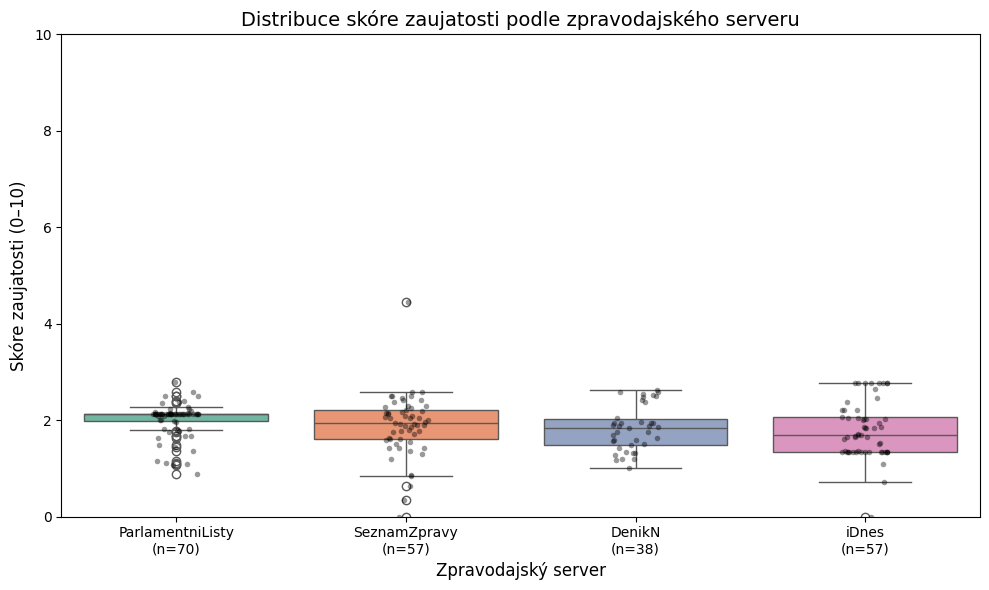

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'all_outlets_df' in locals() and 'refined_bias_corpus_score' in all_outlets_df.columns:

    # Pořadí zdrojů podle mediánu (od nejvíce po nejméně subjektivní)
    source_order = (
        all_outlets_df.groupby('source')['refined_bias_corpus_score']
        .median()
        .sort_values(ascending=False)
        .index.tolist()
    )

    fig, ax = plt.subplots(figsize=(10, 6))

    sns.boxplot(
        data=all_outlets_df,
        x='source', y='refined_bias_corpus_score',
        order=source_order, palette='Set2', ax=ax
    )
    sns.stripplot(
        data=all_outlets_df,
        x='source', y='refined_bias_corpus_score',
        order=source_order, color='black', alpha=0.4, size=4, ax=ax
    )

    # Přidáme počet článků pod každý label
    xtick_labels = [
        f"{s}\n(n={len(all_outlets_df[all_outlets_df['source'] == s])})"
        for s in source_order
    ]
    ax.set_xticklabels(xtick_labels)

    ax.set_title('Distribuce skóre zaujatosti podle zpravodajského serveru', fontsize=14)
    ax.set_xlabel('Zpravodajský server', fontsize=12)
    ax.set_ylabel('Skóre zaujatosti (0–10)', fontsize=12)
    ax.set_ylim(0, 10)

    plt.tight_layout()
    plt.show()
else:
    print("Chybí data pro vizualizaci. Spusťte nejprve buňku 46.")

### 9b. Další pohledy na data

Boxplot a ANOVA jsou dobrý základ, ale přišlo nám, že pro prezentaci se hodí ukázat data z více úhlů najednou. Přidali jsme tři vizualizace, které to doplňují:

1. **Heatmapa korelací** — chceme vědět, jak moc spolu naše různé metriky korelují. Pokud je korelace vysoká, měří v podstatě totéž — pokud nízká, každá zachycuje jiný aspekt subjektivity.
2. **Radar chart** — umožní na jednom místě srovnat profil každého média přes více dimenzí najednou, což v tabulce nebo boxplotu není vidět.
3. **Timeline** — zajímalo nás, jestli se subjektivita mění v čase (například kolem politických událostí). Data máme s datem publikace, tak proč to nezkusit.

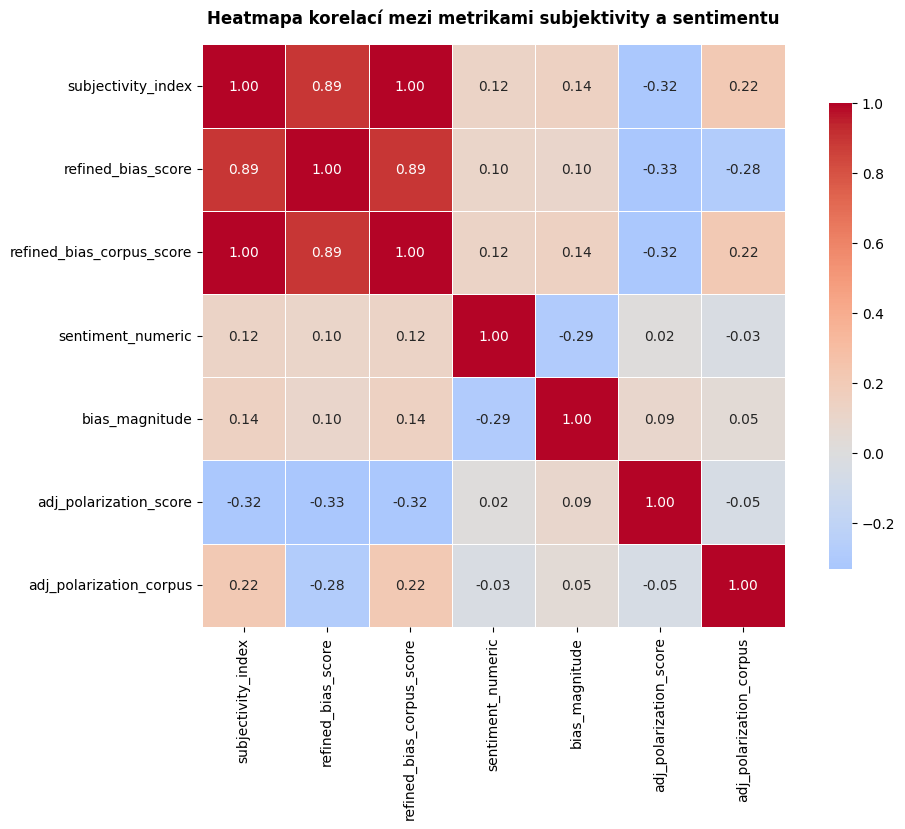

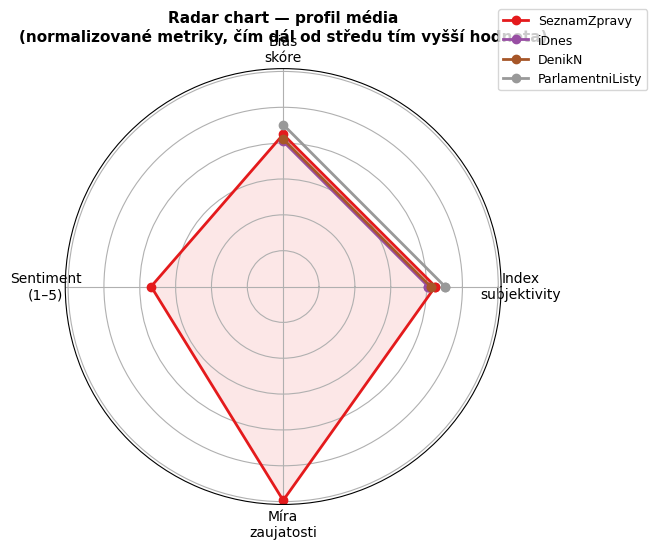

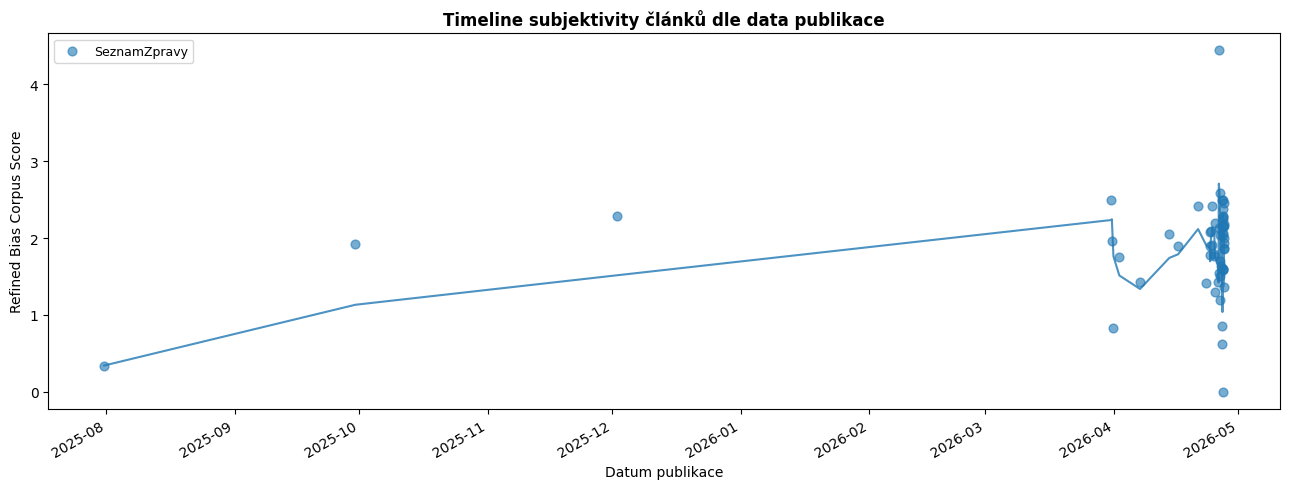

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
import pandas as pd

if 'all_outlets_df' in locals() and not all_outlets_df.empty:
    df = all_outlets_df.copy()

    # ─────────────────────────────────────────────────────────────
    # 1. HEATMAPA KORELACÍ mezi numerickými metrikami
    # ─────────────────────────────────────────────────────────────
    num_cols = [c for c in ['subjectivity_index', 'refined_bias_score',
                             'refined_bias_corpus_score', 'sentiment_numeric',
                             'bias_magnitude', 'adj_polarization_score',
                             'adj_polarization_corpus']
                if c in df.columns]

    if len(num_cols) >= 2:
        corr = df[num_cols].corr()
        fig, ax = plt.subplots(figsize=(len(num_cols) * 1.4 + 1, len(num_cols) * 1.2))
        sns.heatmap(
            corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5,
            ax=ax, cbar_kws={'shrink': 0.8}
        )
        ax.set_title("Heatmapa korelací mezi metrikami subjektivity a sentimentu",
                     fontsize=12, fontweight='bold', pad=15)
        plt.tight_layout()
        plt.show()

    # ─────────────────────────────────────────────────────────────
    # 2. RADAR CHART — profil každého média
    # ─────────────────────────────────────────────────────────────
    radar_cols = [c for c in ['subjectivity_index', 'refined_bias_corpus_score',
                               'sentiment_numeric', 'bias_magnitude']
                  if c in df.columns]
    radar_labels = {
        'subjectivity_index': 'Index\nsubjektivity',
        'refined_bias_corpus_score': 'Bias\nskóre',
        'sentiment_numeric': 'Sentiment\n(1–5)',
        'bias_magnitude': 'Míra\nzaujatosti'
    }

    if len(radar_cols) >= 3:
        sources = df['source'].unique().tolist()
        N = len(radar_cols)
        angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
        angles += angles[:1]  # uzavřeme polygon

        # Normalizujeme metriky na rozsah 0–1 per sloupec
        df_norm = df.copy()
        for col in radar_cols:
            mn, mx = df[col].min(), df[col].max()
            df_norm[col] = (df[col] - mn) / (mx - mn + 1e-9)

        fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
        colors = plt.cm.Set1(np.linspace(0, 1, len(sources)))

        for src, color in zip(sources, colors):
            vals = df_norm[df_norm['source'] == src][radar_cols].mean().tolist()
            vals += vals[:1]
            ax.plot(angles, vals, 'o-', linewidth=2, color=color, label=src)
            ax.fill(angles, vals, alpha=0.10, color=color)

        ax.set_xticks(angles[:-1])
        ax.set_xticklabels([radar_labels.get(c, c) for c in radar_cols], size=10)
        ax.set_yticklabels([])
        ax.set_title("Radar chart — profil média\n(normalizované metriky, čím dál od středu tím vyšší hodnota)",
                     fontsize=11, fontweight='bold', pad=20)
        ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)
        plt.tight_layout()
        plt.show()

    # ─────────────────────────────────────────────────────────────
    # 3. TIMELINE subjektivity dle data publikace
    # ─────────────────────────────────────────────────────────────
    score_col = ('refined_bias_corpus_score' if 'refined_bias_corpus_score' in df.columns
                 else 'subjectivity_index')

    if 'publish_date' in df.columns:
        df_time = df[['source', 'publish_date', score_col]].copy()
        df_time['publish_date'] = pd.to_datetime(df_time['publish_date'], errors='coerce', utc=True)
        df_time = df_time.dropna(subset=['publish_date'])
        df_time = df_time.sort_values('publish_date')

        if len(df_time) > 3:
            fig, ax = plt.subplots(figsize=(13, 5))
            sources = df_time['source'].unique()
            colors = plt.cm.tab10(np.linspace(0, 1, len(sources)))

            for src, color in zip(sources, colors):
                sub = df_time[df_time['source'] == src]
                ax.scatter(sub['publish_date'], sub[score_col],
                           color=color, alpha=0.6, s=40, label=src)
                # Klouzavý průměr (pokud dost bodů)
                if len(sub) >= 3:
                    sub_sorted = sub.sort_values('publish_date')
                    ax.plot(sub_sorted['publish_date'],
                            sub_sorted[score_col].rolling(3, min_periods=1).mean(),
                            color=color, linewidth=1.5, alpha=0.8)

            ax.set_xlabel("Datum publikace")
            ax.set_ylabel(score_col.replace('_', ' ').title())
            ax.set_title("Timeline subjektivity článků dle data publikace",
                         fontsize=12, fontweight='bold')
            ax.legend(loc='upper left', fontsize=9)
            fig.autofmt_xdate()
            plt.tight_layout()
            plt.show()
        else:
            print("Nedostatek datumových dat pro timeline (potřeba alespoň 4 články s datem).")
    else:
        print("Sloupec 'publish_date' není k dispozici.")

else:
    print("Chybí all_outlets_df. Spusťte nejprve sekci 8 (multi-source scraping).")

### 10. Dashboarding — Interaktivní scatter plot

Jako finální vizualizaci jsme udělali interaktivní scatter plot přes Plotly, kde každý bod je jeden článek. Osa X je index subjektivity, osa Y je sentiment — a po najetí myší se zobrazí titulek článku a jeho klíčová slova z TF-IDF.

Přišlo nám, že tahle vizualizace je ideální pro prezentaci — publikum může samo explorovat data a hledat zajímavé články na okrajích grafu. Barevné škálování podle sentimentu navíc přidá třetí dimenzi bez toho, aby byl graf nepřehledný.

In [ ]:
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd

if 'articles_df' in locals() and 'subjectivity_index' in articles_df.columns and 'sentiment_label' in articles_df.columns:

    # Convert sentiment label ("1 star" … "5 stars") to a numeric 1–5 score
    def label_to_numeric(label):
        try:
            return int(str(label).split()[0])
        except (ValueError, IndexError):
            return None

    plot_df = articles_df.copy()
    plot_df['sentiment_numeric'] = plot_df['sentiment_label'].apply(label_to_numeric)

    # Use best available subjectivity score
    subjectivity_col = 'refined_bias_corpus_score' if 'refined_bias_corpus_score' in plot_df.columns else \
                       'refined_bias_score'         if 'refined_bias_score'         in plot_df.columns else \
                       'subjectivity_index'
    print(f"[Graf] Použité skóre subjektivity: '{subjectivity_col}'")

    # Build hover text
    if 'top_keywords' in plot_df.columns:
        plot_df['hover_keywords'] = plot_df['top_keywords']
    else:
        plot_df['hover_keywords'] = ''

    plot_df = plot_df.dropna(subset=[subjectivity_col, 'sentiment_numeric'])

    x_min = plot_df[subjectivity_col].min()
    x_max = plot_df[subjectivity_col].max()

    fig = px.scatter(
        plot_df,
        x=subjectivity_col,
        y='sentiment_numeric',
        hover_name='title',
        hover_data={'hover_keywords': True, subjectivity_col: ':.3f', 'sentiment_numeric': True},
        color='sentiment_numeric',
        color_continuous_scale='RdYlGn',
        size_max=14,
        labels={
            subjectivity_col: 'Index subjektivity',
            'sentiment_numeric': 'Sentiment (1 = neg., 5 = poz.)',
            'hover_keywords': 'Klíčová slova',
        },
        title='Subjektivita vs. Sentiment článků (najeďte myší pro detail)',
    )

    fig.update_traces(
        marker=dict(size=12, line=dict(width=1, color='DarkSlateGrey')),
        selector=dict(mode='markers'),
    )

    subjectivity_explanation = (
        "<b>Index subjektivity</b> měří poměr<br>"
        "popisných slov (přídavná jména +<br>"
        "příslovce) k faktickým slovům<br>"
        "(podstatná jména + slovesa).<br>"
        "<b>Nízká hodnota</b> → objektivní styl<br>"
        "<b>Vysoká hodnota</b> → subjektivní styl<br>"
        "<br>"
        "<b>Sentiment</b> je detekován modelem<br>"
        "BERT (nlptown) na škále 1–5 hvězdiček.<br>"
        "<b>1 hvězdička</b> → velmi negativní tón<br>"
        "<b>5 hvězdiček</b> → velmi pozitivní tón"
    )

    fig.update_layout(
        xaxis_title='Index subjektivity  ◀ objektivní · subjektivní ▶',
        yaxis_title='▲ pozitivní  ·  Sentiment (1–5 hvězdiček)  ·  negativní ▼',
        yaxis=dict(tickmode='linear', tick0=1, dtick=1, range=[0.5, 5.5]),
        coloraxis_colorbar=dict(title='Sentiment'),
        hovermode='closest',
        height=580,
        annotations=[
            # Explanation box
            dict(
                text=subjectivity_explanation,
                xref='paper', yref='paper',
                x=1.18, y=0.5,
                showarrow=False,
                align='left',
                bgcolor='rgba(240,248,255,0.92)',
                bordercolor='steelblue',
                borderwidth=1,
                borderpad=8,
                font=dict(size=11),
            ),
            # X-axis low label
            dict(
                text='Objektivní',
                xref='x', yref='paper',
                x=x_min, y=-0.14,
                showarrow=False,
                font=dict(size=10, color='steelblue'),
                align='center',
            ),
            # X-axis high label
            dict(
                text='Subjektivní',
                xref='x', yref='paper',
                x=x_max, y=-0.14,
                showarrow=False,
                font=dict(size=10, color='firebrick'),
                align='center',
            ),
            # Y-axis low label (1 = negative)
            dict(
                text='Negativní',
                xref='paper', yref='y',
                x=-0.13, y=1,
                showarrow=False,
                font=dict(size=10, color='firebrick'),
                align='center',
            ),
            # Y-axis high label (5 = positive)
            dict(
                text='Pozitivní',
                xref='paper', yref='y',
                x=-0.13, y=5,
                showarrow=False,
                font=dict(size=10, color='green'),
                align='center',
            ),
        ],
        margin=dict(b=80, l=100, r=260),
    )

    fig.show()
else:
    print("Chybí potřebné sloupce (subjectivity_index, sentiment_label). Spusťte nejprve buňky 28 a 30.")

[Graf] Použité skóre subjektivity: 'refined_bias_score'
